# Configuración del Entorno

In [ ]:
# Configuración inicial del entorno
import sys
import warnings
warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

print(f"✅ Python {sys.version_info.major}.{sys.version_info.minor} instalado correctamente")

✅ Python 3.12 instalado correctamente


In [ ]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# Verificar versiones de librerías críticas
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"✅ scikit-learn {sklearn.__version__} instalado")

✅ scikit-learn 1.6.1 instalado


# Descargar Dataset

[Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

In [ ]:
import tarfile
import zipfile
import urllib.request

def load_students_data():
    data_path = Path("datasets")
    data_path.mkdir(parents=True, exist_ok=True)

    zip_path = data_path / "students_performance.zip"
    extract_dir = data_path / "students_performance"
    csv_path = data_path / "students_performance" / "StudentsPerformance.csv"

    if csv_path.is_file():
        print("Cargando datos desde caché local...")
        return pd.read_csv(csv_path)

    if not zip_path.is_file():
        print("Descargando dataset...")
        url = "https://github.com/Adrephos/machinelearning/raw/refs/heads/master/data/students_performance.zip"
        try:
            urllib.request.urlretrieve(url, zip_path)
            print("Descarga completada")
        except Exception as e:
            print(f"Error en descarga: {e}")
            return None

    print("Extrayendo archivos...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        bad = zf.testzip()
        if bad is not None:
            raise zipfile.BadZipFile(f"Archivo corrupto en el ZIP: {bad}")
        zf.extractall(path=extract_dir)


    print("Datos cargados exitosamente")
    return pd.read_csv(csv_path)

performance = load_students_data()
print(f"\nDataset cargado: {performance.shape[0]:,} filas × {performance.shape[1]} columnas")

Cargando datos desde caché local...

Dataset cargado: 1,000 filas × 8 columnas


# Vista general del Dataset

In [ ]:
# Vista general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET".center(80))
print("=" * 80)

display(performance.head())

# Información detallada
print("\n" + "=" * 80)
print("ESTRUCTURA DE DATOS".center(80))
print("=" * 80)
performance.info()

# Estadísticas descriptivas
print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS".center(80))
print("=" * 80)
display(performance.describe().round(2).T)

                        INFORMACIÓN GENERAL DEL DATASET                         


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



                              ESTRUCTURA DE DATOS                               
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

                           ESTADÍSTICAS DESCRIPTIVAS                            


,count,mean,std,min,25%,50%,75%,max
math score,1000.00,66.09,15.16,0.00,57.00,66.00,77.00,100.00
reading score,1000.00,69.17,14.60,17.00,59.00,70.00,79.00,100.00
writing score,1000.00,68.05,15.20,10.00,57.75,69.00,79.00,100.00


## Variables demográficas

- gender Sexo del estudiante (male, female). Permite analizar posibles diferencias de desempeño académico entre géneros.
- race/ethnicity Agrupación categórica de origen racial/étnico (group A, B, C, D, E). Puede reflejar diferencias en contexto sociocultural o acceso a recursos educativos.
- parental level of education Nivel educativo de los padres (high school, some college, bachelor’s, master’s, etc.). Sirve como un indicador socioeconómico y cultural relevante en el rendimiento escolar.
## Variables socioeconómicas

- lunch Tipo de almuerzo recibido (standard o free/reduced). Funciona como un proxy de nivel socioeconómico: quienes reciben almuerzo gratuito o reducido suelen pertenecer a familias con menos recursos.
- test preparation course Si el estudiante completó o no un curso de preparación para los exámenes. Relacionado con acceso a recursos adicionales y preparación académica.

## Variables de desempeño académico (numéricas)

- math score Puntaje en matemáticas (0–100). Variable cuantitativa continua.
- reading score Puntaje en lectura (0–100). Permite comparar habilidades de comprensión verbal.
- writing score Puntaje en escritura (0–100). Complementa las habilidades de lenguaje junto con lectura

In [ ]:
# Diccionario de metadatos
metadata = {
    'Variable': [
        'gender',
        'race/ethnicity',
        'parental level of education',
        'lunch',
        'test preparation course',
        'math score',
        'reading score',
        'writing score'
    ],
    'Tipo': [
        'Categórica',
        'Categórica',
        'Categórica',
        'Categórica',
        'Categórica',
        'Numérica',
        'Numérica',
        'Numérica'
    ],
    'Descripción': [
        'Género del estudiante (male/female)',
        'Grupo racial/étnico asignado (A, B, C, D, E)',
        'Nivel educativo de los padres (high school, bachelor, master, etc.)',
        'Tipo de almuerzo recibido (standard o free/reduced)',
        'Participación en curso de preparación de examen (none/completed)',
        'Puntaje obtenido en matemáticas (0–100)',
        'Puntaje obtenido en lectura (0–100)',
        'Puntaje obtenido en escritura (0–100)'
    ],
    'Valores Faltantes': [
        performance['gender'].isnull().sum(),
        performance['race/ethnicity'].isnull().sum(),
        performance['parental level of education'].isnull().sum(),
        performance['lunch'].isnull().sum(),
        performance['test preparation course'].isnull().sum(),
        performance['math score'].isnull().sum(),
        performance['reading score'].isnull().sum(),
        performance['writing score'].isnull().sum()
    ]
}

df_metadata = pd.DataFrame(metadata)
display(df_metadata)

,Variable,Tipo,Descripción,Valores Faltantes
0,gender,Categórica,Género del estudiante (male/female),0
1,race/ethnicity,Categórica,"Grupo racial/étnico asignado (A, B, C, D, E)",0
2,parental level of education,Categórica,"Nivel educativo de los padres (high school, ba...",0
3,lunch,Categórica,Tipo de almuerzo recibido (standard o free/red...,0
4,test preparation course,Categórica,Participación en curso de preparación de exame...,0
5,math score,Numérica,Puntaje obtenido en matemáticas (0–100),0
6,reading score,Numérica,Puntaje obtenido en lectura (0–100),0
7,writing score,Numérica,Puntaje obtenido en escritura (0–100),0


In [ ]:
def analyze_missing_values(df):
    """Análisis completo de valores faltantes"""
    missing_df = pd.DataFrame({
        'Columna': df.columns,
        'Valores_Faltantes': df.isnull().sum(),
        'Porcentaje': (df.isnull().sum() / len(df)) * 100,
        'Tipo_Dato': df.dtypes
    })

    missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values(
        'Porcentaje', ascending=False
    )

    if len(missing_df) > 0:
        # Visualización
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Gráfico de barras
        ax1.bar(missing_df['Columna'], missing_df['Porcentaje'], color='coral')
        ax1.set_xlabel('Columna')
        ax1.set_ylabel('Porcentaje de Valores Faltantes (%)')
        ax1.set_title('Valores Faltantes por Columna')
        ax1.axhline(y=5, color='r', linestyle='--', label='Umbral 5%')
        ax1.legend()

        # Heatmap de patrones
        import seaborn as sns
        msno_data = df[missing_df['Columna'].tolist()].isnull().astype(int)
        sns.heatmap(msno_data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                   ax=ax2, vmin=-1, vmax=1)
        ax2.set_title('Correlación de Patrones de Valores Faltantes')

        plt.tight_layout()
        plt.show()

        return missing_df
    else:
        print("✅ No hay valores faltantes en el dataset")
        return None

missing_analysis = analyze_missing_values(performance)
if missing_analysis is not None:
    display(missing_analysis)

✅ No hay valores faltantes en el dataset


## Estadísticas descriptivas: Los números cuentan historias

### 1. Media vs. Mediana
- **Math score** → media = 66.09, mediana = 66.00 → distribución simétrica, no hay sesgo importante.  
- **Reading score** → media = 69.17, mediana = 70.00 → media < mediana → ligero sesgo a la izquierda (más valores bajos que altos).  
- **Writing score** → media = 68.05, mediana = 69.00 → media < mediana → también sesgo a la izquierda, aunque leve.  

En general, las distribuciones de puntajes son bastante equilibradas, con apenas un sesgo hacia los valores bajos en lectura y escritura.

---

### 2. Desviación estándar
- Math: 15.16  
- Reading: 14.60  
- Writing: 15.20  

La desviación es relativamente similar en las tres áreas (~15 puntos).  
Esto significa que hay variabilidad considerable en los puntajes: algunos estudiantes se desempeñan muy mal (<40) mientras otros obtienen puntajes perfectos (100).

---

### 3. Min/Max sospechosos
- Mínimos: math = 0, reading = 17, writing = 10.  
  - El 0 en matemáticas podría ser un caso extremo (estudiante ausente o fallo en el examen).  
- Máximos: todos llegan a 100.  
  - Sugiere que el examen tenía un puntaje máximo fijo (no hay censura, simplemente es el límite natural del test).  

---

### 4. Rango intercuartílico (IQR)
- En todos los casos, el 50% central de los estudiantes está entre aproximadamente 57 y 79 puntos.  
- Esto muestra que la mayoría tiene rendimiento medio, con extremos que generan la variabilidad.

---

### Conclusión general
El dataset refleja un grupo de estudiantes con desempeño bastante equilibrado entre lectura, escritura y matemáticas.  
Sin embargo, la dispersión alta indica grandes desigualdades: hay estudiantes con puntajes muy bajos junto a otros con puntajes perfectos.  
La ligera asimetría hacia puntajes bajos en lectura y escritura podría relacionarse con factores socioeconómicos o de preparación.


# Preparación de los datos

Antes de comenzar a entrenar los modelos y anilizar más los datos, decidimos hacer algunos modificaciones a los datos. Dado que las notas de las 3 materias están muy correlacionadas, se decidió agregar 2 columnas más.

- **Percentage**: Esta columna va a ser el promedio de las 3 materias, y será el soporte para la siguiente columna
- **Grade**: Colmna con la calificación que el estudiante obtiene en el promedio de las 3 materias, está va a estar dada por el sistema usado en muchas instituciones educativas de los Estados Unidos. dependiendo del valor de "Percentage", el estudiante puede optener los siguientes valores en "Grade":

  | Grade | Percentage |
  |--------|-------------|
  | A | 90–100% |
  | B | 80–89% |
  | C | 70–79% |
  | D | 60–69% |
  | F | 0–59% |

In [ ]:
def grade(percentage):
    if (percentage >= 60):return 'PASS'
    else: return 'FAIL'

# Add performance column
performance['percentage'] = (performance['math score']+performance['reading score']+performance['writing score'])/3

# Add grade column
performance["grade"] = performance.apply(lambda x : grade(x["percentage"]), axis=1)

performance.head()
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   percentage                   1000 non-null   float64
 9   grade                        1000 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 78.3+ KB


# Analisis Univariado
## Variables Númericas

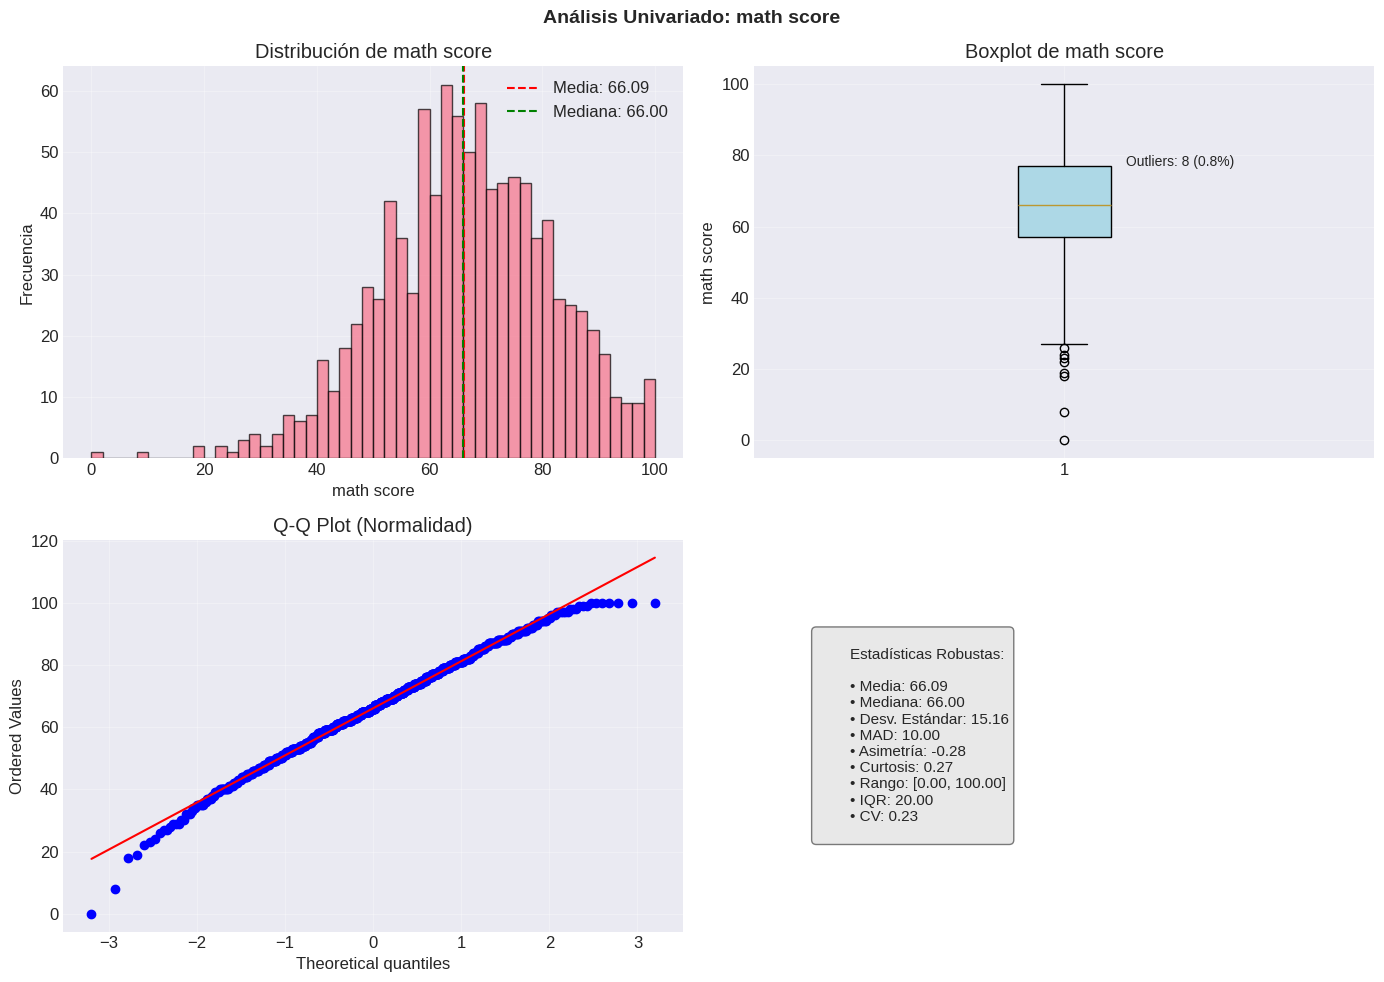

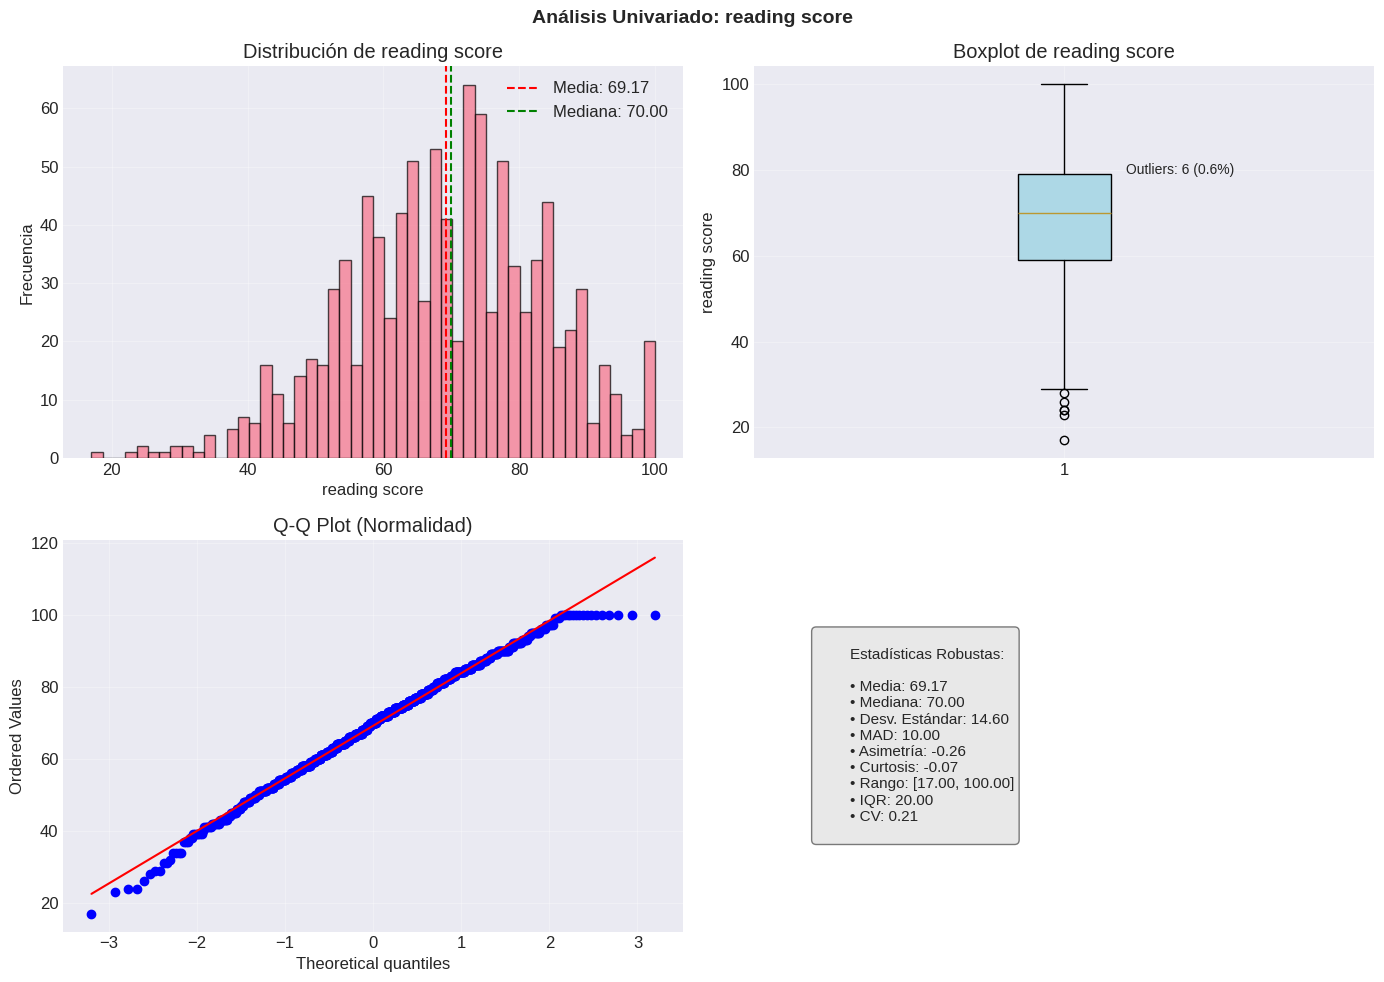

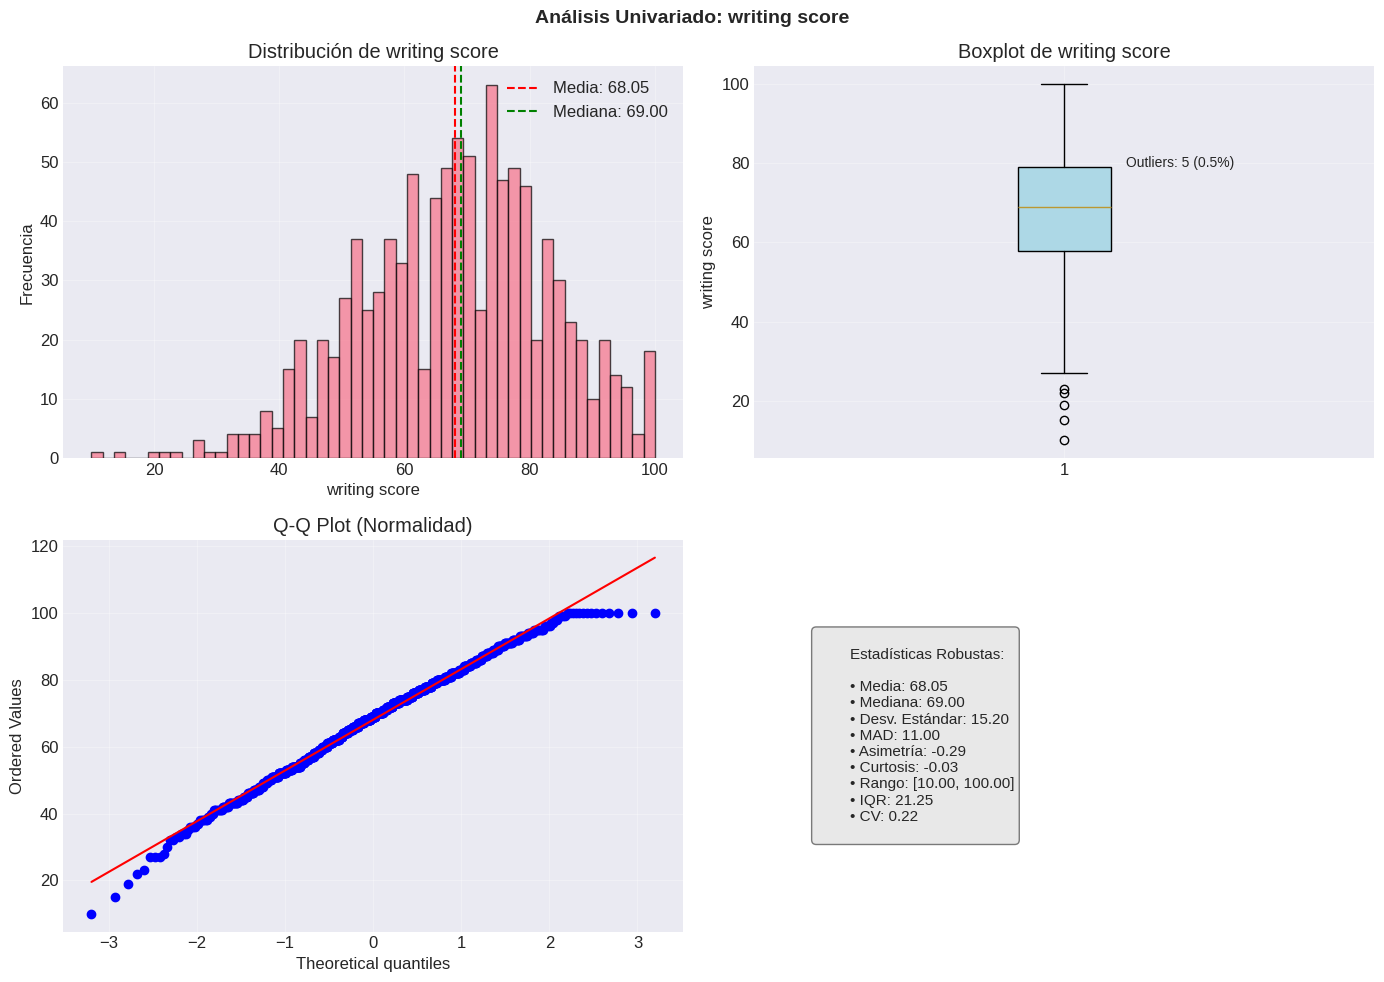

In [ ]:
# Función para análisis univariado robusto
def univariate_analysis(df, column, target=None):
    """Análisis univariado con estadísticas robustas"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Histograma con KDE
    ax1 = axes[0, 0]
    df[column].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax1)
    ax1.axvline(df[column].mean(), color='red', linestyle='--', label=f'Media: {df[column].mean():.2f}')
    ax1.axvline(df[column].median(), color='green', linestyle='--', label=f'Mediana: {df[column].median():.2f}')
    ax1.set_title(f'Distribución de {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Frecuencia')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Boxplot
    ax2 = axes[0, 1]
    bp = ax2.boxplot(df[column].dropna(), vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    ax2.set_title(f'Boxplot de {column}')
    ax2.set_ylabel(column)
    ax2.grid(alpha=0.3)

    # Detectar outliers
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)]
    ax2.text(1.1, Q3, f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)',
             fontsize=10)

    # 3. Q-Q Plot
    ax3 = axes[1, 0]
    from scipy import stats
    stats.probplot(df[column].dropna(), dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot (Normalidad)')
    ax3.grid(alpha=0.3)

    # 4. Relación con target (si existe)
    ax4 = axes[1, 1]
    if target is not None and target in df.columns:
        ax4.scatter(df[column], df[target], alpha=0.5, s=10)
        ax4.set_xlabel(column)
        ax4.set_ylabel(target)
        ax4.set_title(f'{column} vs {target}')

        # Agregar línea de tendencia
        z = np.polyfit(df[column].dropna(), df[target][df[column].notna()], 1)
        p = np.poly1d(z)
        ax4.plot(df[column].sort_values(), p(df[column].sort_values()),
                "r--", alpha=0.8, label=f'Tendencia')

        # Calcular correlación
        corr = df[column].corr(df[target])
        ax4.text(0.05, 0.95, f'Correlación: {corr:.3f}',
                transform=ax4.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat'))
        ax4.legend()
    else:
        # Estadísticas adicionales
        ax4.axis('off')
        stats_text = f"""
        Estadísticas Robustas:

        • Media: {df[column].mean():.2f}
        • Mediana: {df[column].median():.2f}
        • Desv. Estándar: {df[column].std():.2f}
        • MAD: {stats.median_abs_deviation(df[column].dropna()):.2f}
        • Asimetría: {df[column].skew():.2f}
        • Curtosis: {df[column].kurtosis():.2f}
        • Rango: [{df[column].min():.2f}, {df[column].max():.2f}]
        • IQR: {IQR:.2f}
        • CV: {df[column].std()/df[column].mean():.2f}
        """
        ax4.text(0.1, 0.5, stats_text, transform=ax4.transAxes,
                fontsize=11, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    ax4.grid(alpha=0.3)

    plt.suptitle(f'Análisis Univariado: {column}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Analizar variables numéricas clave
for col in ['math score', 'reading score', 'writing score']:
    univariate_analysis(performance, col)

## Variables Categóricas

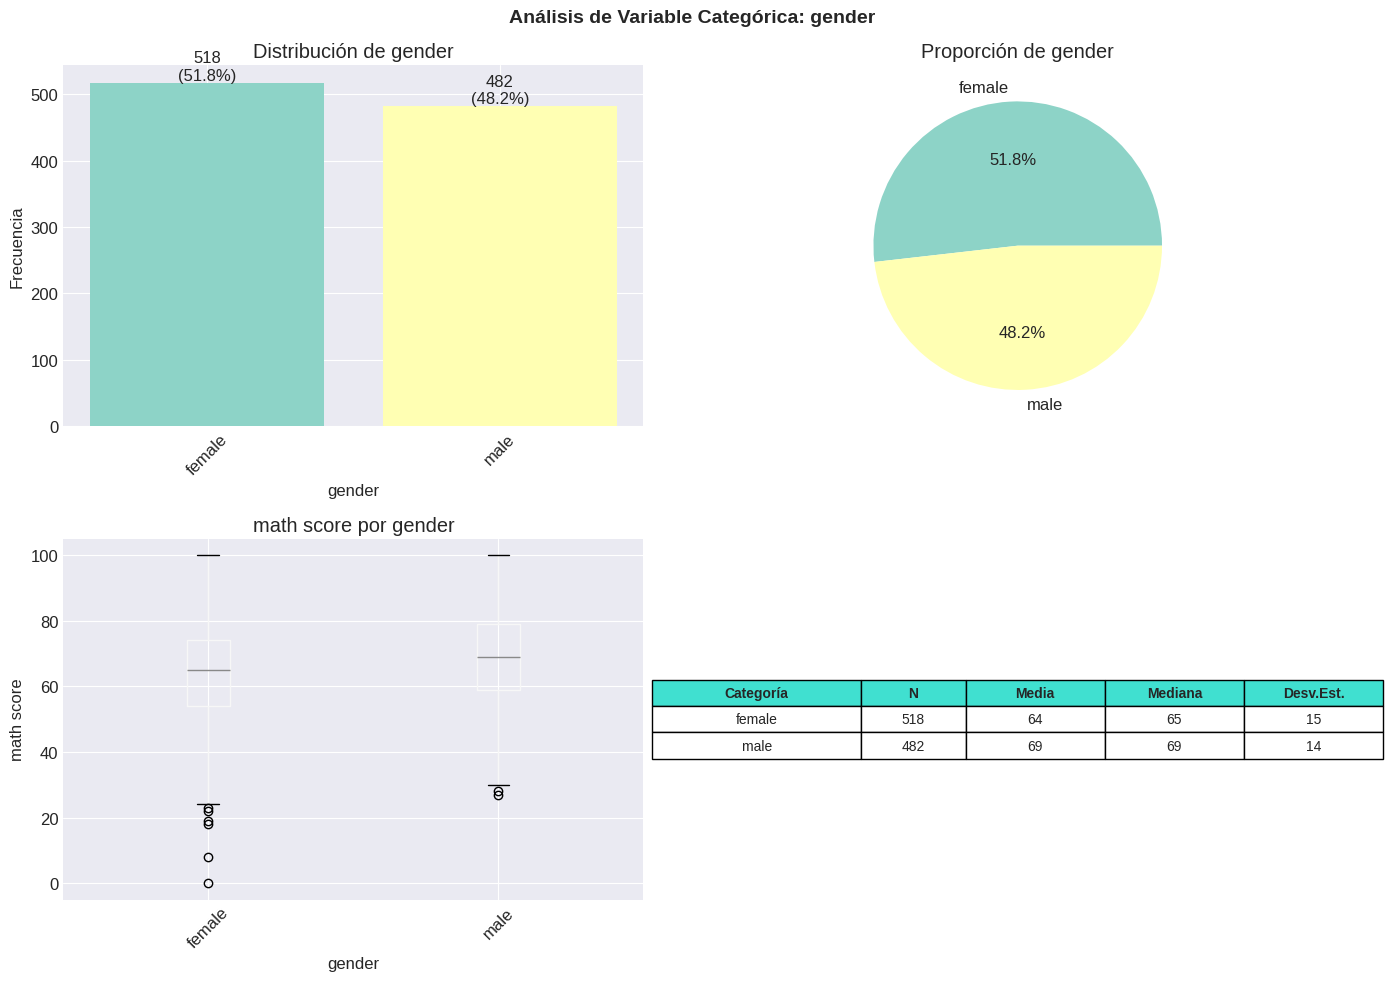

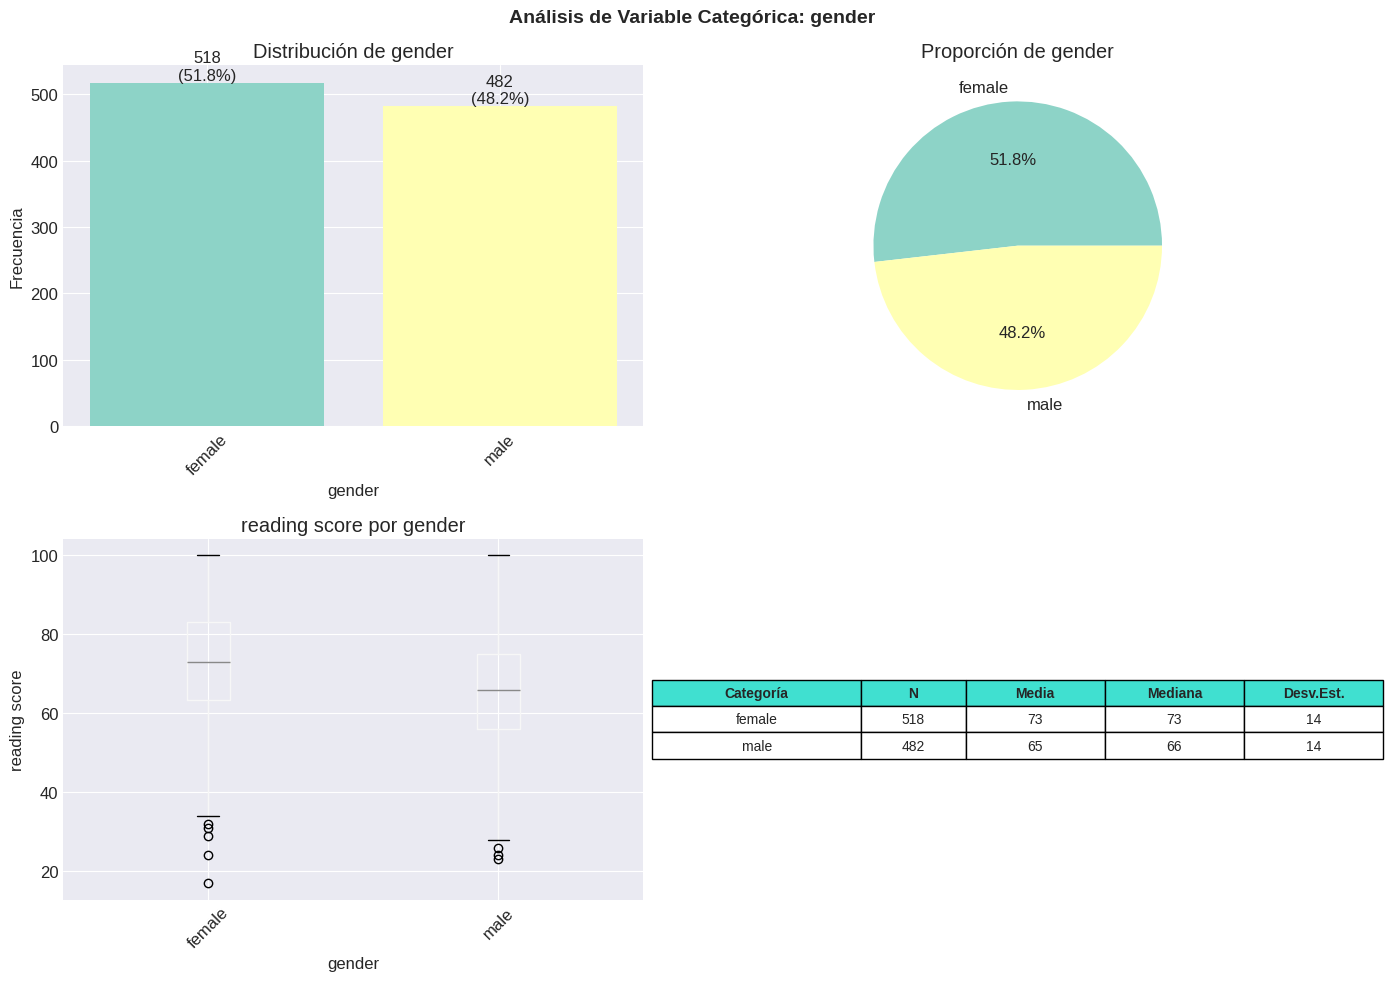

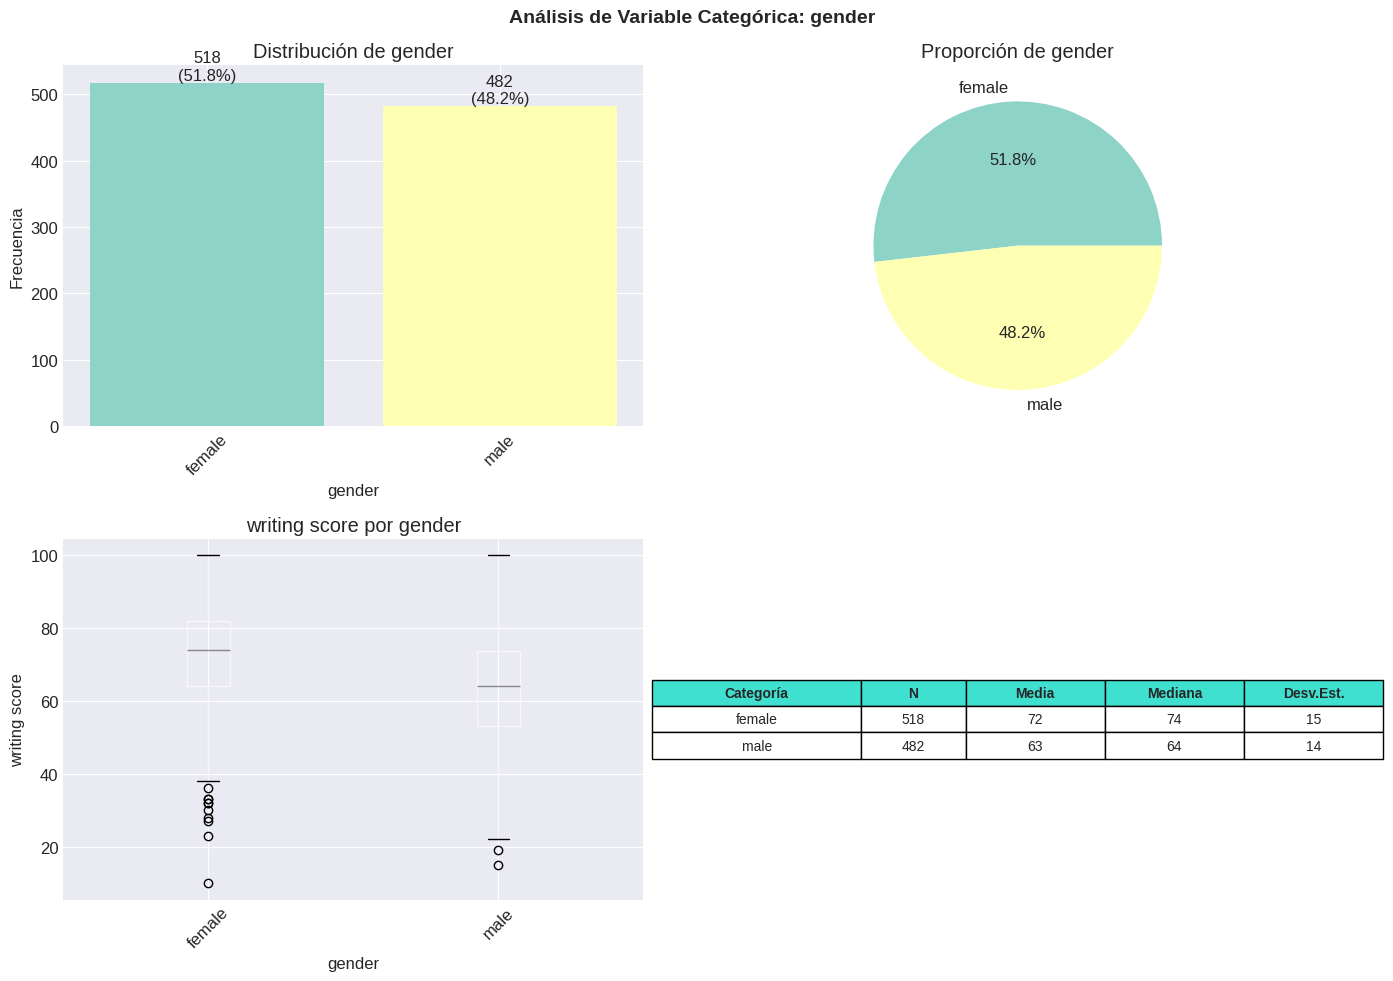

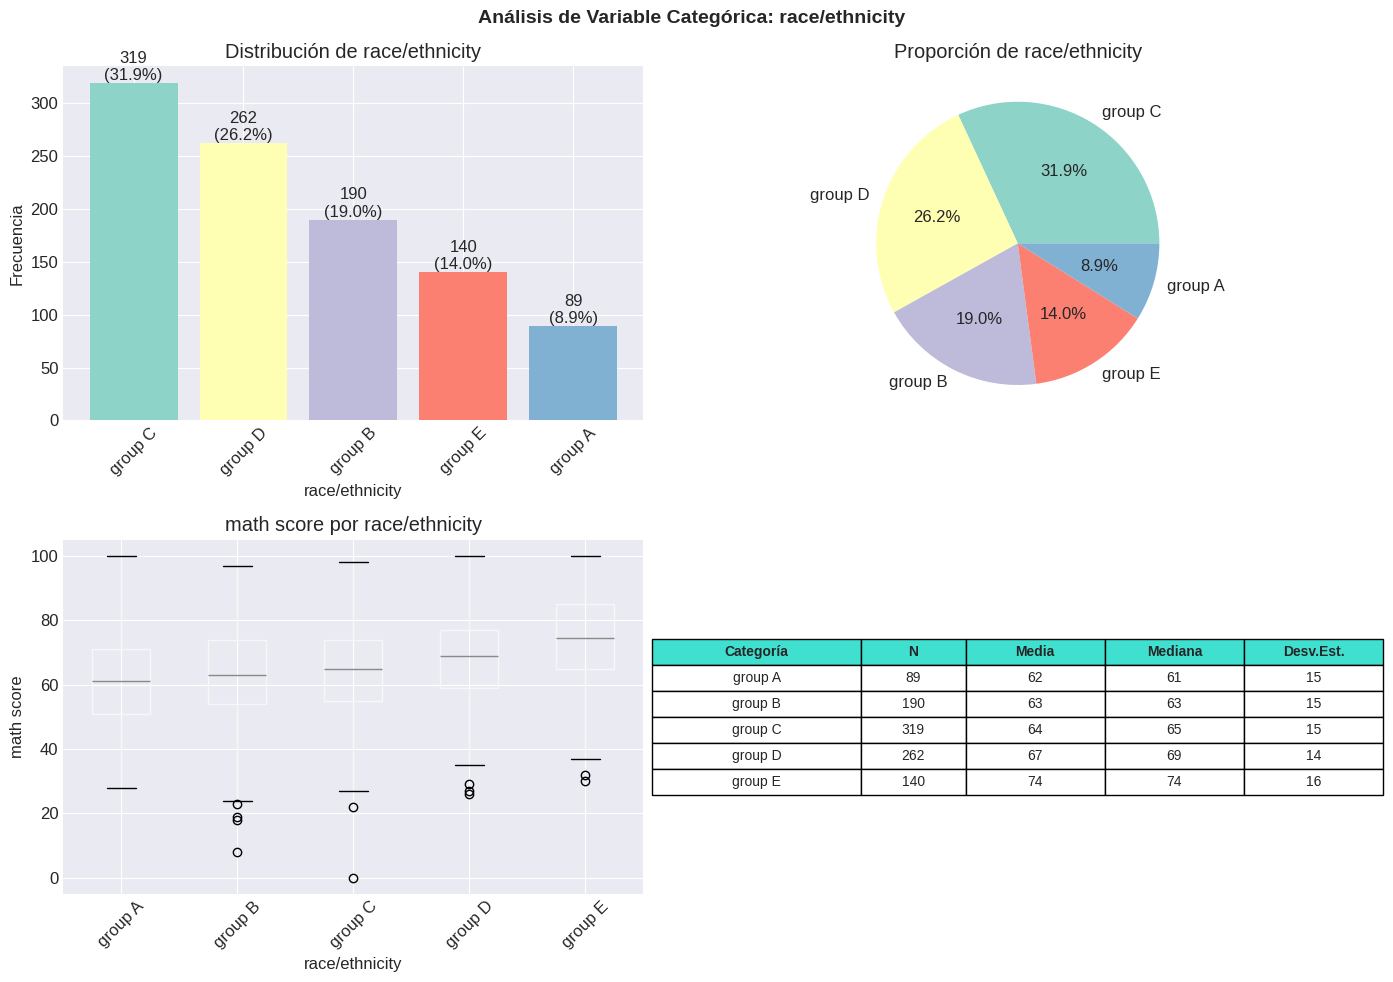

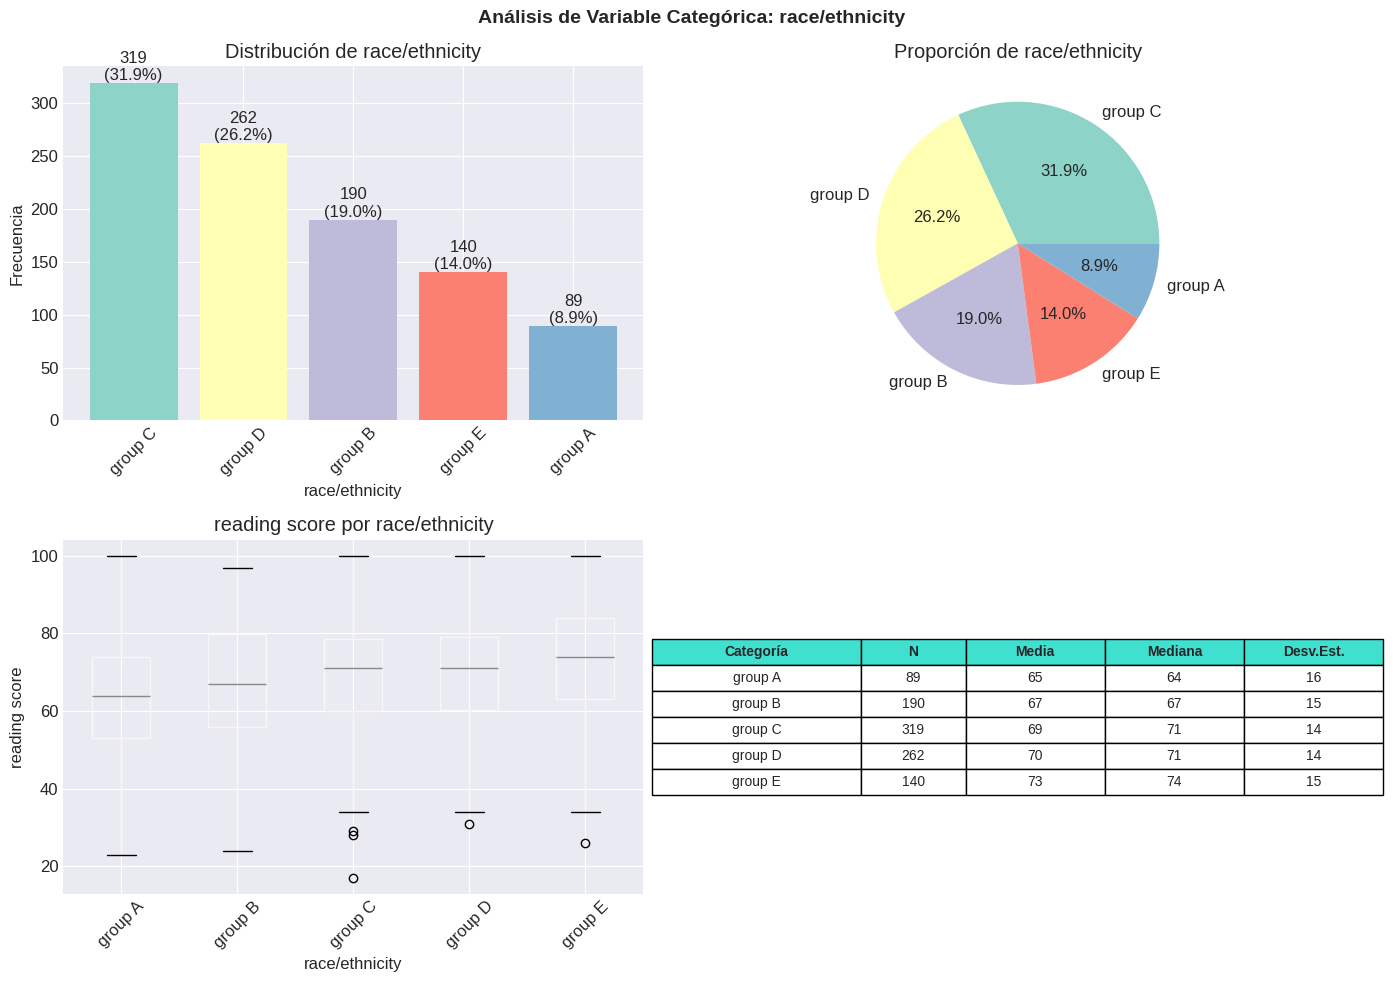

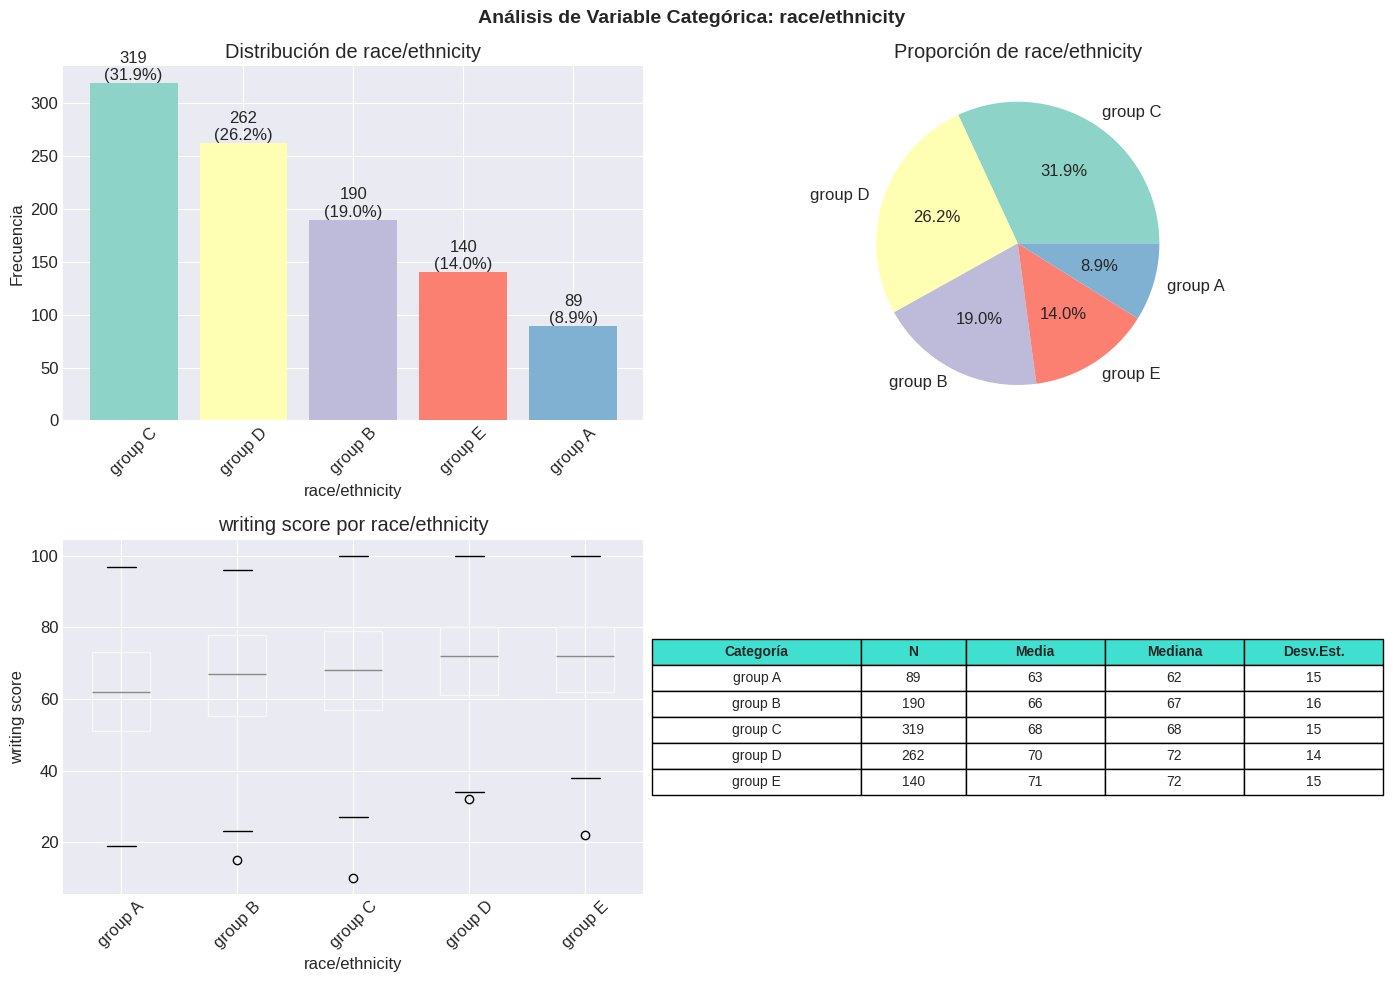

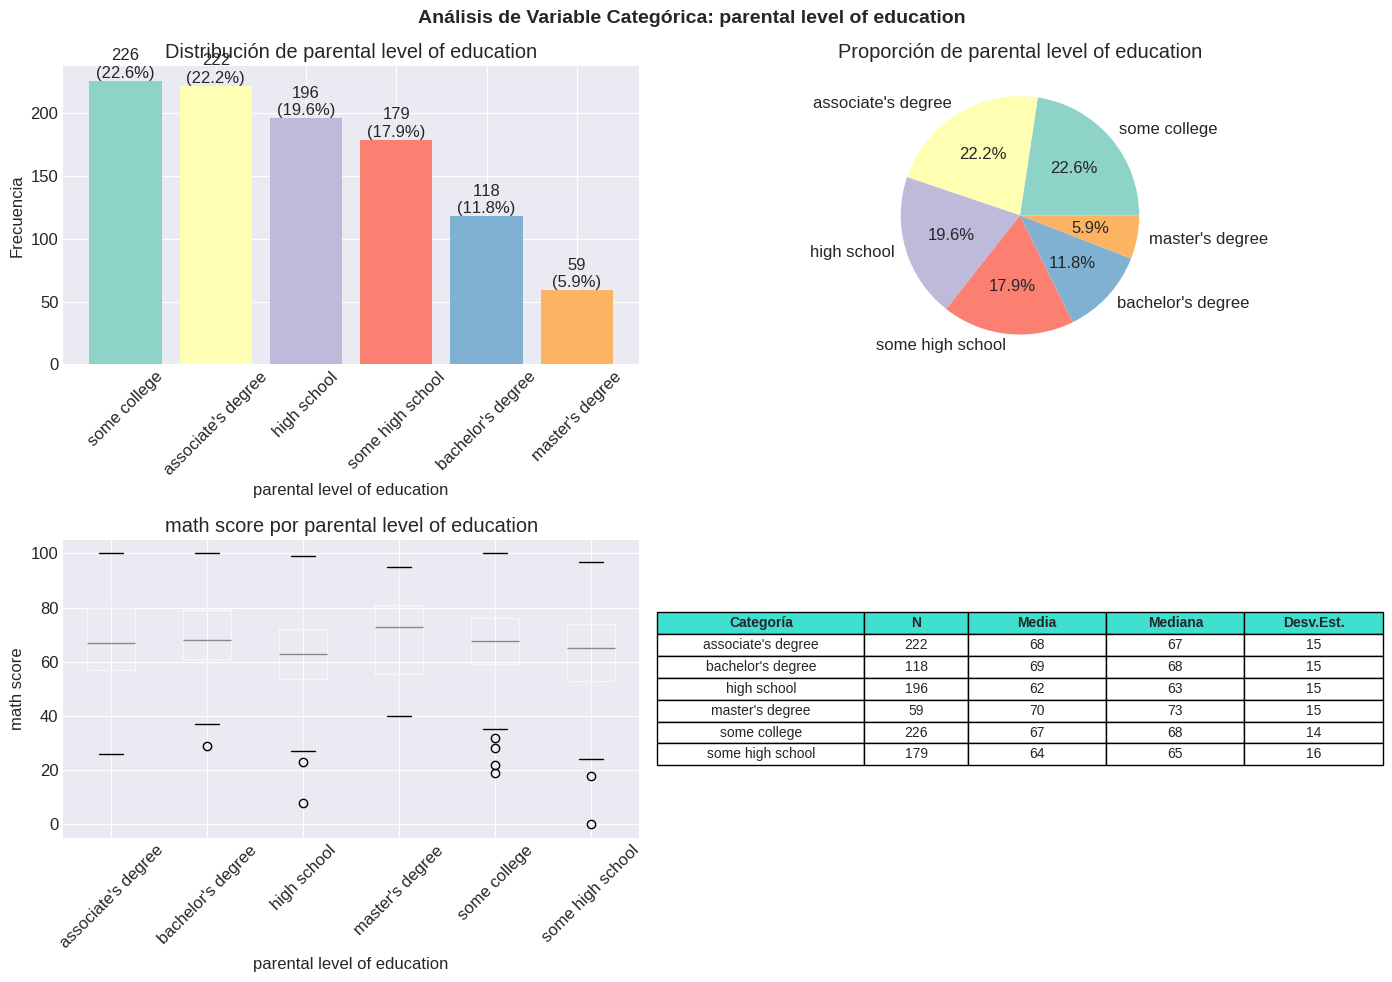

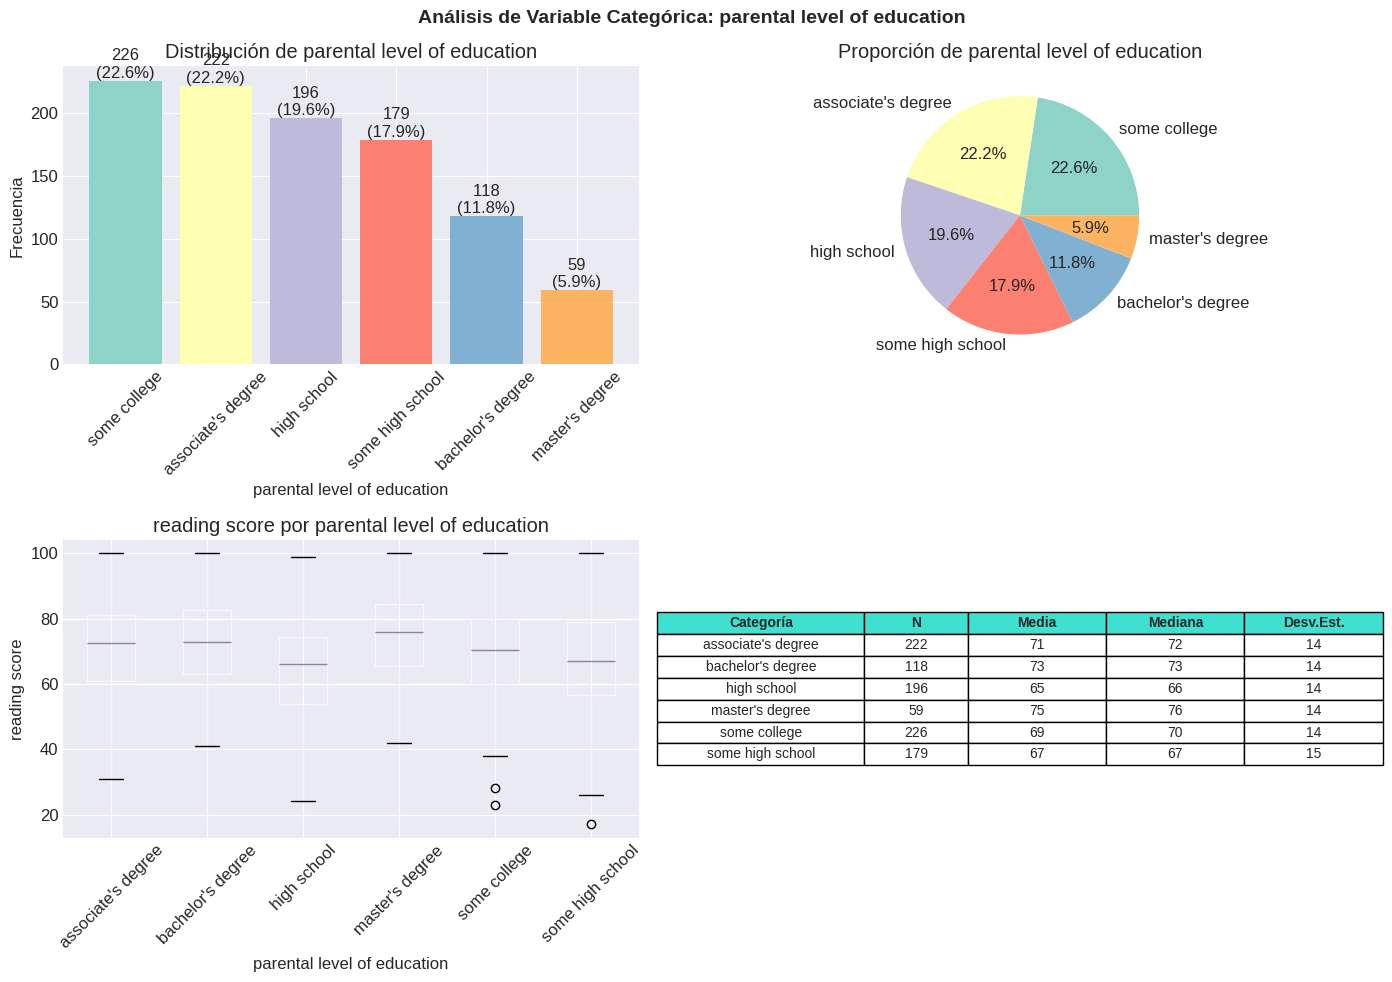

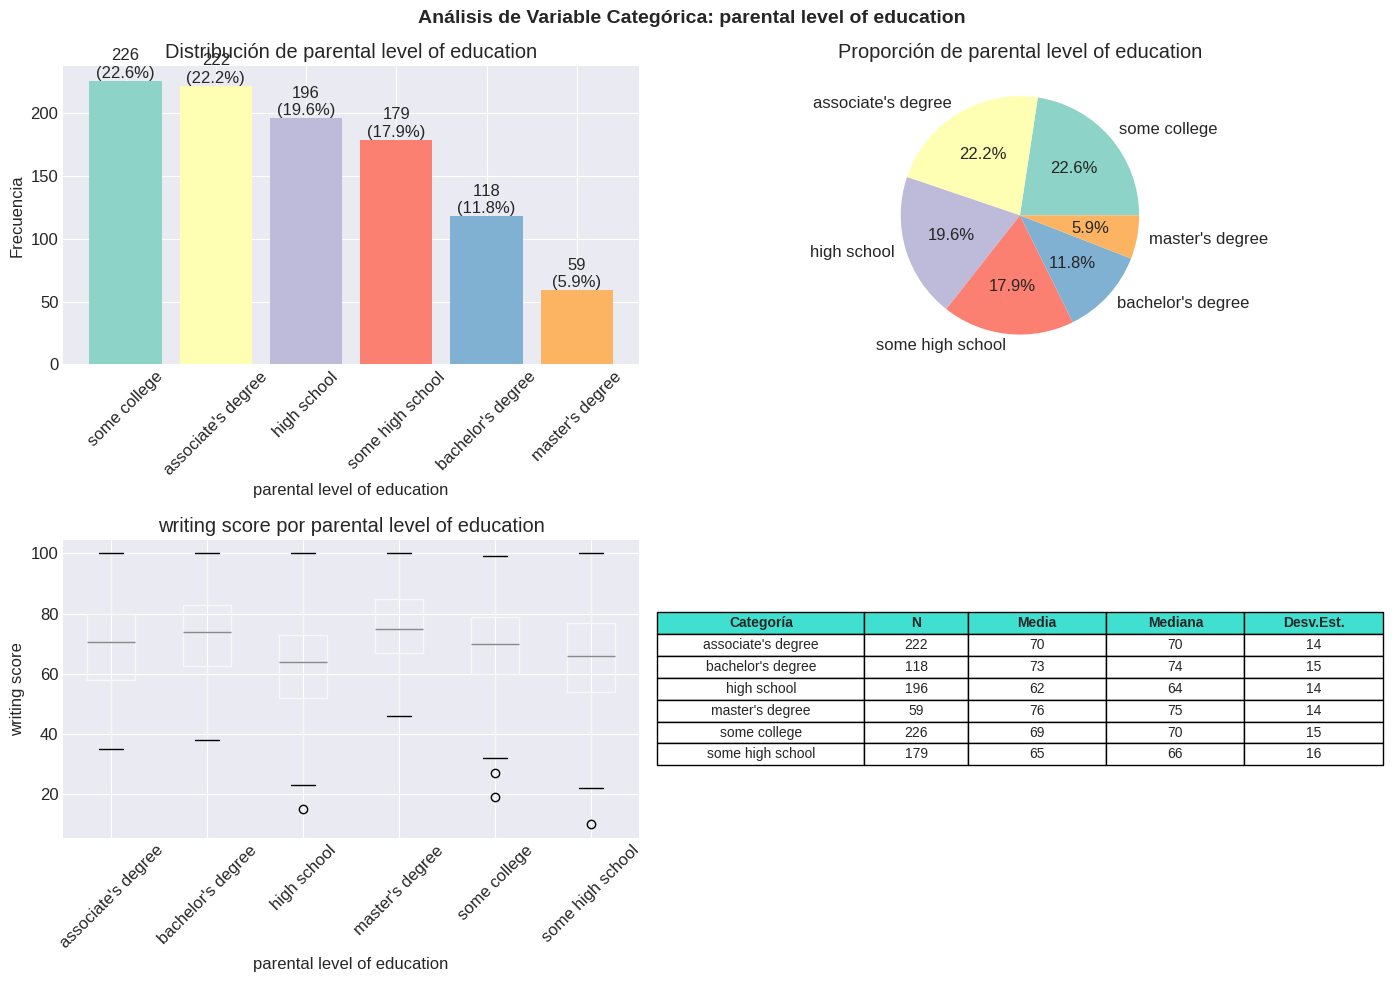

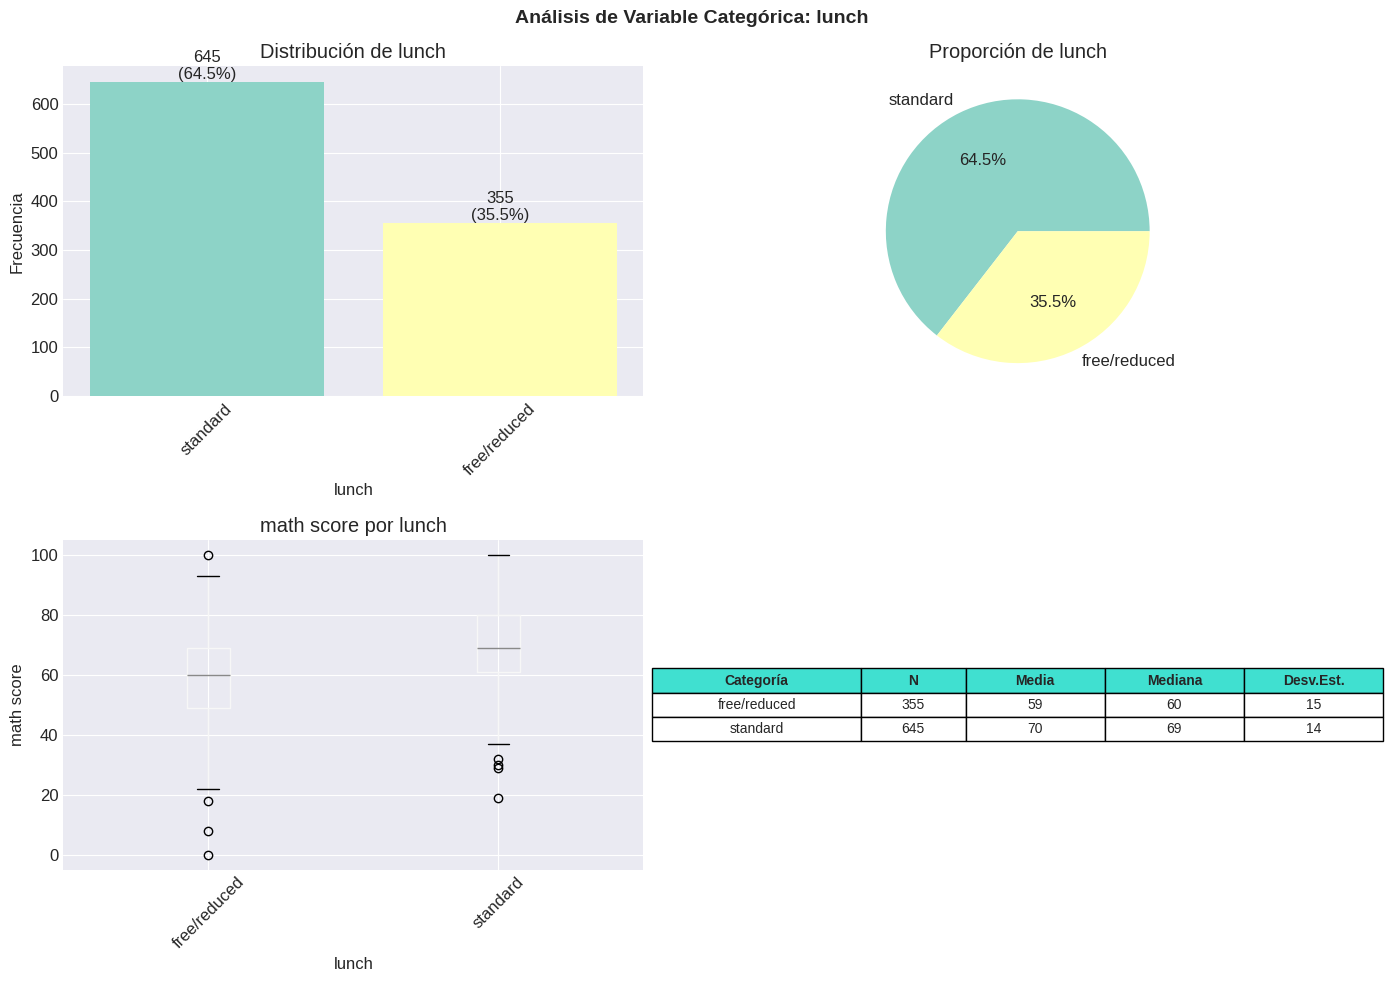

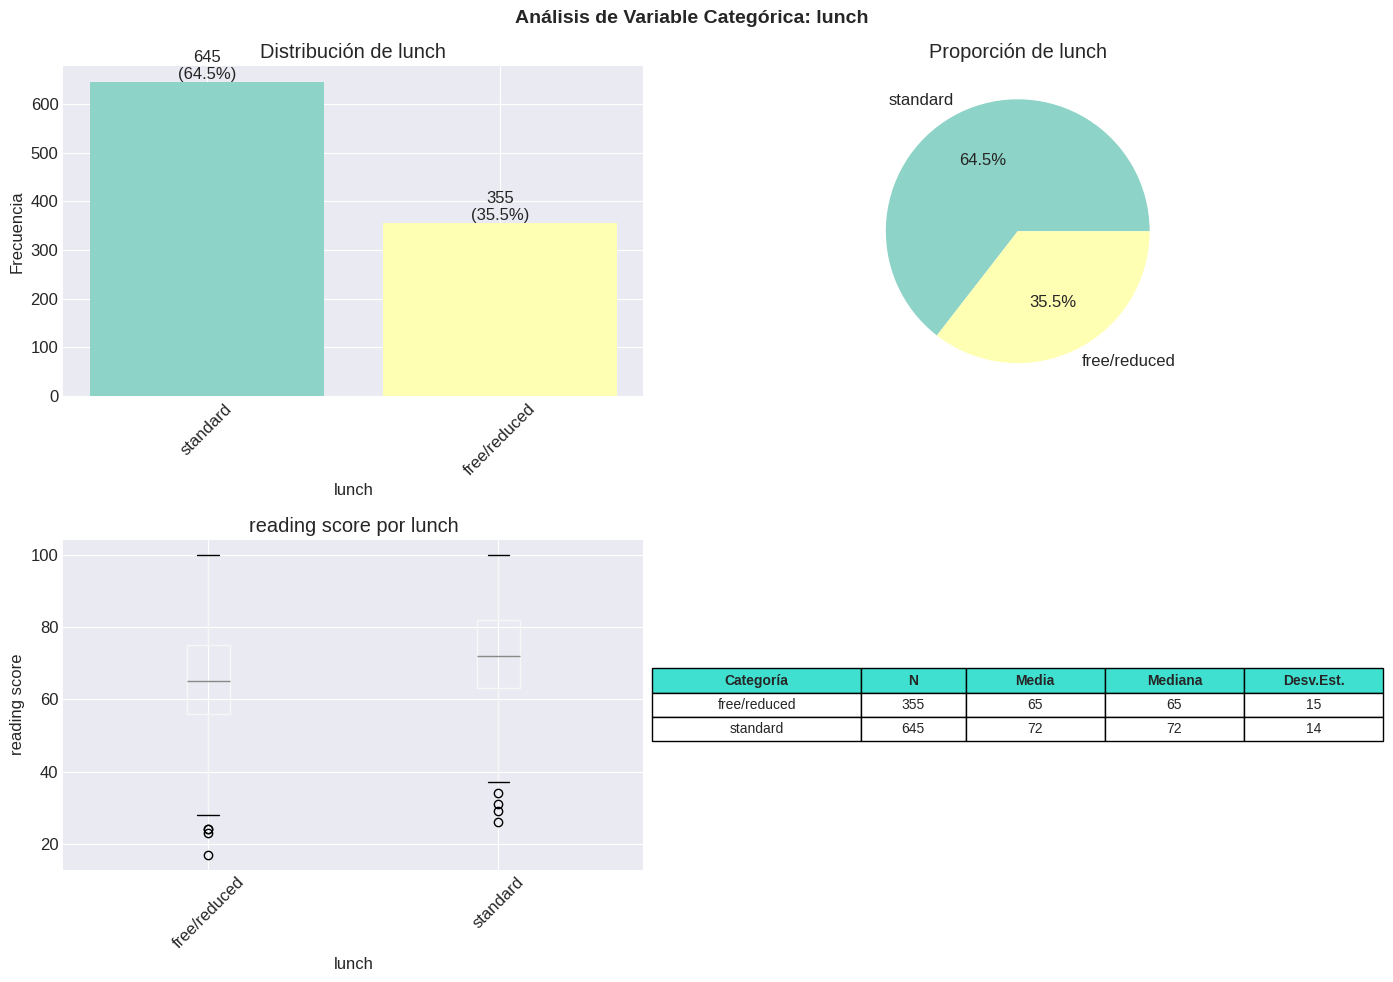

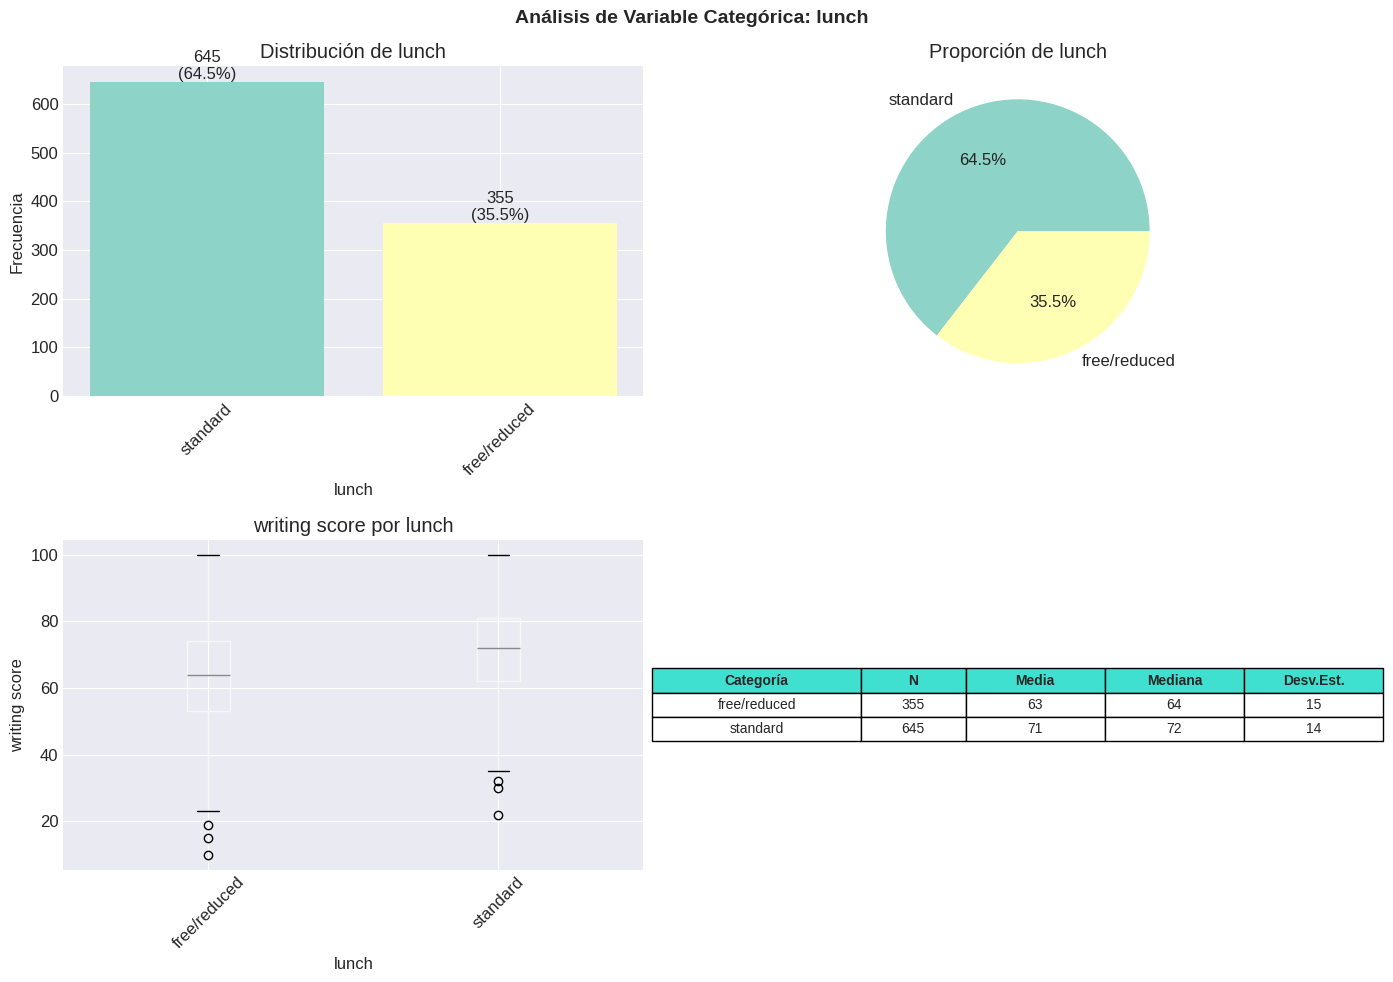

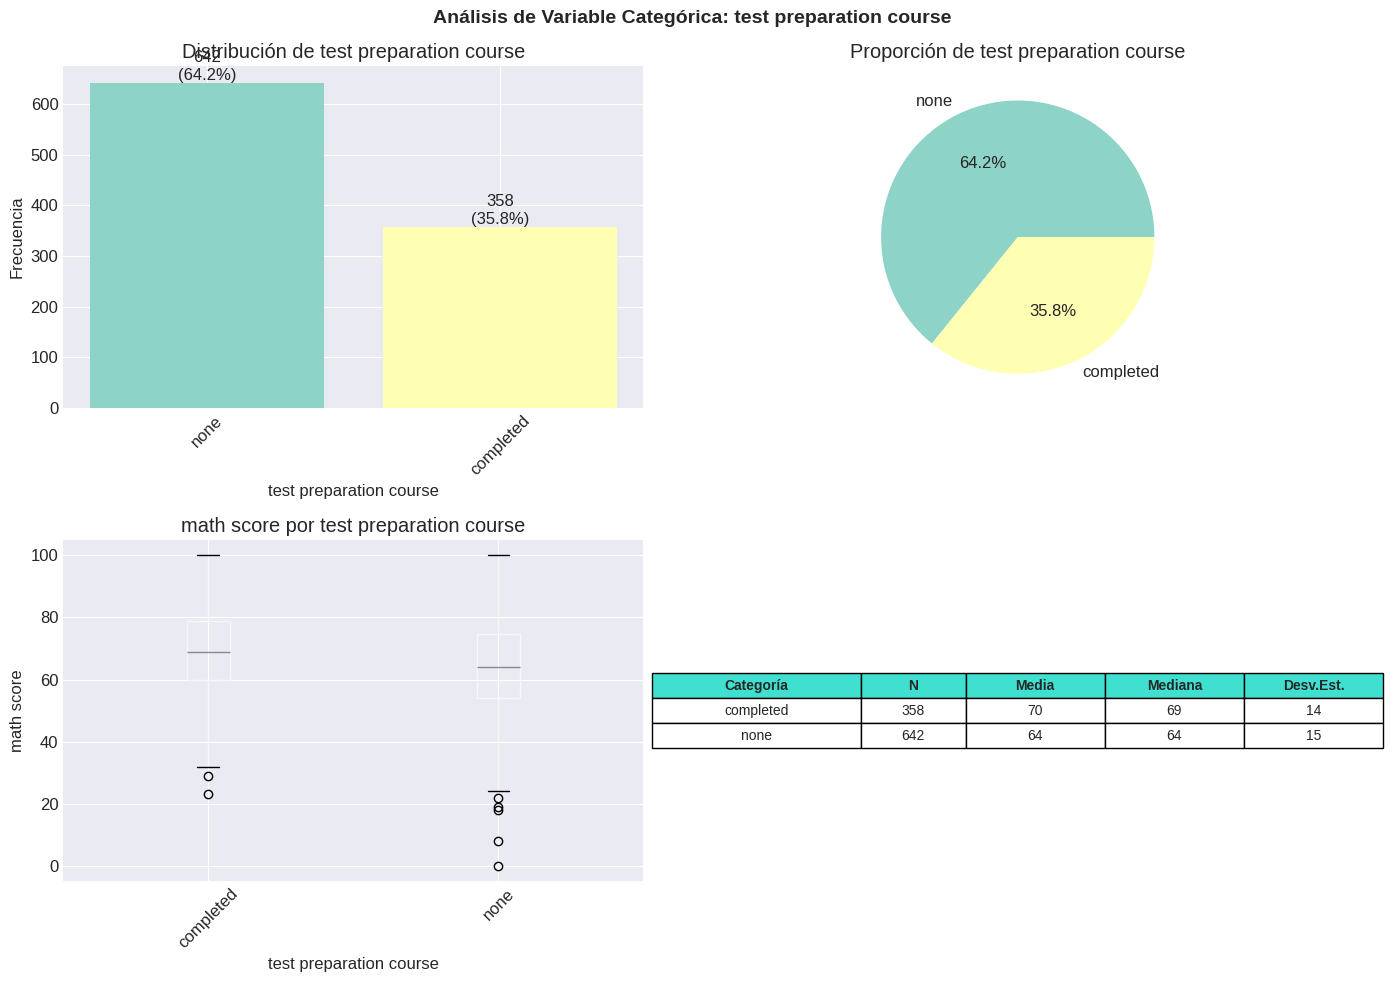

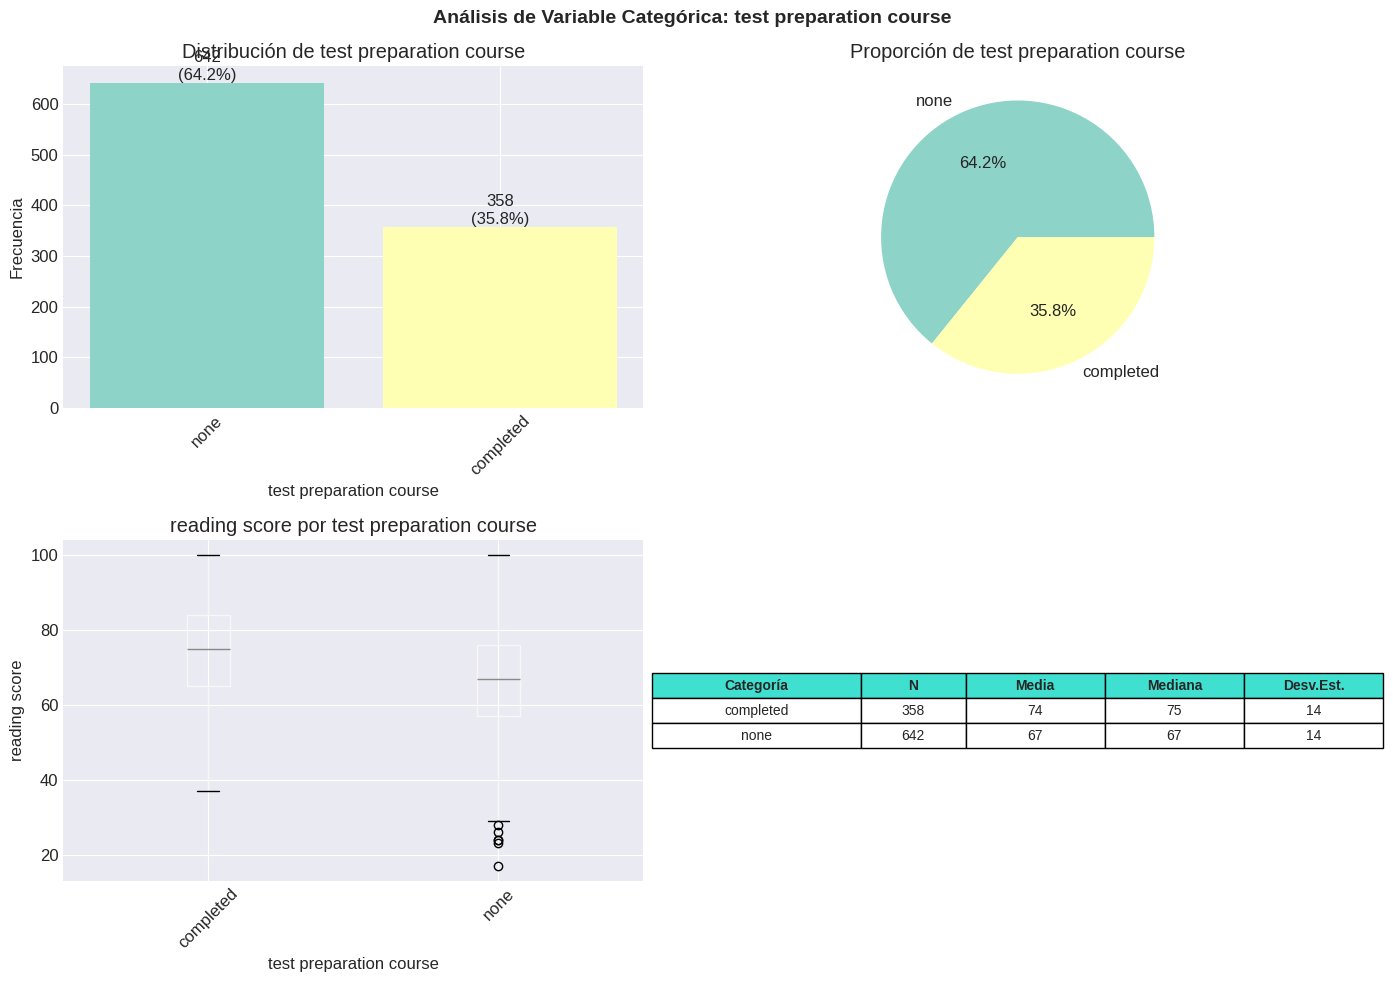

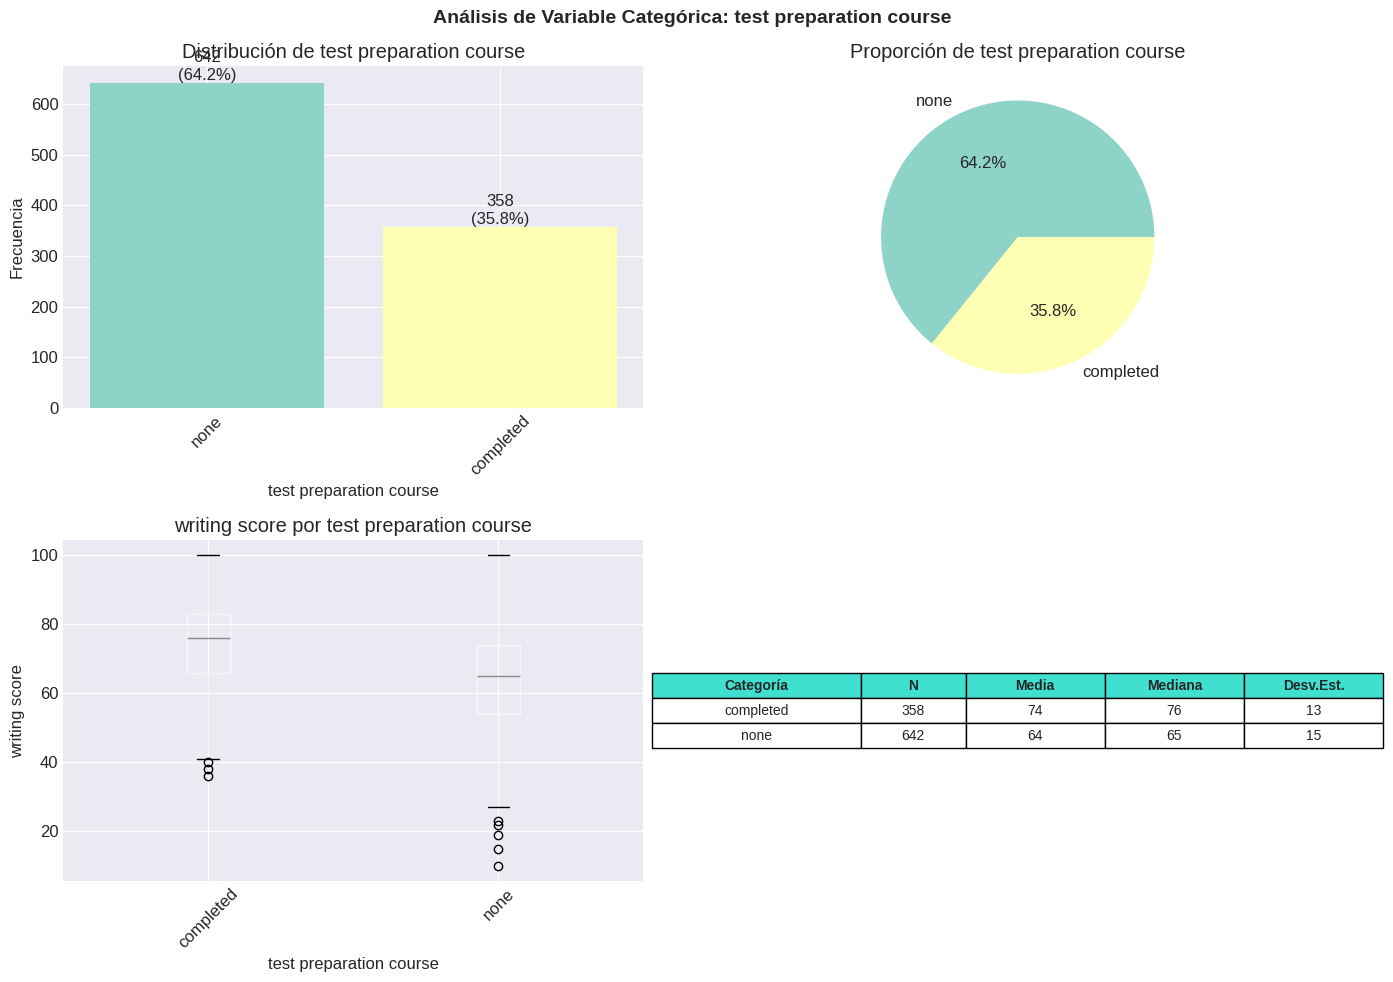

In [ ]:
# Análisis de ocean_proximity
def analyze_categorical(df, cat_col, target_col):
    """Análisis completo de variable categórica"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Distribución de categorías
    ax1 = axes[0, 0]
    counts = df[cat_col].value_counts()
    ax1.bar(counts.index, counts.values, color=plt.cm.Set3(range(len(counts))))
    ax1.set_title(f'Distribución de {cat_col}')
    ax1.set_xlabel(cat_col)
    ax1.set_ylabel('Frecuencia')
    ax1.tick_params(axis='x', rotation=45)

    # Agregar porcentajes
    for i, (idx, val) in enumerate(counts.items()):
        ax1.text(i, val, f'{val}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom')

    # 2. Pie chart
    ax2 = axes[0, 1]
    ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=plt.cm.Set3(range(len(counts))))
    ax2.set_title(f'Proporción de {cat_col}')

    # 3. Boxplot por categoría
    ax3 = axes[1, 0]
    df.boxplot(column=target_col, by=cat_col, ax=ax3)
    ax3.set_title(f'{target_col} por {cat_col}')
    ax3.set_xlabel(cat_col)
    ax3.set_ylabel(target_col)
    plt.sca(ax3)
    plt.xticks(rotation=45)

    # 4. Estadísticas por categoría
    ax4 = axes[1, 1]
    ax4.axis('off')

    stats_by_cat = df.groupby(cat_col)[target_col].agg([
        'count', 'mean', 'median', 'std'
    ]).round(2)

    table_data = []
    for idx, row in stats_by_cat.iterrows():
        table_data.append([idx, f"{row['count']:.0f}",
                          f"{row['mean']:,.0f}",
                          f"{row['median']:,.0f}",
                          f"{row['std']:,.0f}"])

    table = ax4.table(cellText=table_data,
                     colLabels=['Categoría', 'N', 'Media', 'Mediana', 'Desv.Est.'],
                     cellLoc='center',
                     loc='center',
                     colWidths=[0.3, 0.15, 0.2, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    # Colorear encabezados
    for i in range(5):
        table[(0, i)].set_facecolor('#40E0D0')
        table[(0, i)].set_text_props(weight='bold')

    plt.suptitle(f'Análisis de Variable Categórica: {cat_col}',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

categorical_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

target_cols = ['math score', 'reading score', 'writing score']

for cat in categorical_cols:
    for target in target_cols:
        analyze_categorical(performance, cat, target)


# Matriz de Correlación

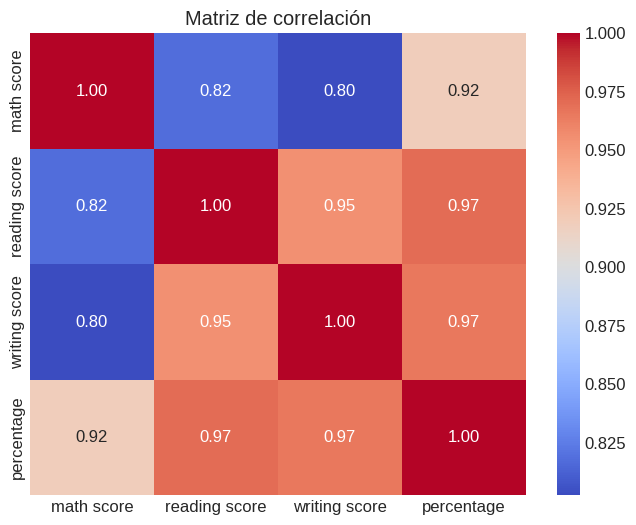

Significant correlations (>|0.5|):
reading score  percentage      0.97
writing score  percentage      0.97
reading score  writing score   0.95
math score     percentage      0.92
               reading score   0.82
               writing score   0.80
dtype: float64

Moderate correlations (>|0.3| and ≤|0.5|):
Series([], dtype: float64)


In [ ]:
# Matriz de correlación entre los scores
corr_matrix = performance.corr(numeric_only=True)

# Plot de la matriz
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

# Imprimir correlaciones significativas
corr_pairs = corr_matrix.unstack().drop_duplicates().sort_values(ascending=False)

significant = corr_pairs[(corr_pairs < 1) & (corr_pairs.abs() > 0.5)]
moderate = corr_pairs[(corr_pairs.abs() > 0.3) & (corr_pairs.abs() <= 0.5)]

print("Significant correlations (>|0.5|):")
print(significant)

print("\nModerate correlations (>|0.3| and ≤|0.5|):")
print(moderate)

La conclusión principal que se puede sacar de esas matrices de correlación es que **las tres variables (`math score`, `reading score` y `writing score`) están fuertemente correlacionadas entre sí**:  

1. **Correlación fuerte y positiva en todos los casos**  
   - Entre `math score` y `reading score`: ~0.82  
   - Entre `math score` y `writing score`: ~0.80  
   - Entre `reading score` y `writing score`: ~0.95 (la más alta de todas).  

   Esto significa que cuando un estudiante obtiene un puntaje alto en una de las áreas, tiende a obtenerlo también en las otras.

2. **Redundancia de información**  
   Dado que las tres variables están muy correlacionadas, existe mucha **colinealidad**. Esto implica que usar las tres como predictores en un modelo puede ser redundante. En la práctica, bastaría con una o dos de ellas, ya que aportan casi la misma información.

3. **Intercambiabilidad como variable objetivo**  
   Dado que cualquiera de las tres tiene correlaciones similares con las demás, se puede elegir `math score`, `reading score` o `writing score` como variable objetivo, y el modelo probablemente tendrá un desempeño similar al predecir una u otra.

4. **Interpretación educativa**  
   Estas correlaciones tan fuertes indican que las competencias en matemáticas, lectura y escritura no son aisladas: un buen desempeño en una suele reflejar un buen desempeño en las demás. Es decir, probablemente haya un **factor académico común** que influye en los tres puntajes.

---

**En resumen:**  
- Las tres variables están muy relacionadas.  
- `reading score` y `writing score` son prácticamente intercambiables (correlación ~0.95).  
- Se puede usar cualquiera de las tres como target, pero para evitar redundancia, conviene no usarlas todas a la vez como features.

# Detección de anomalías y outliers

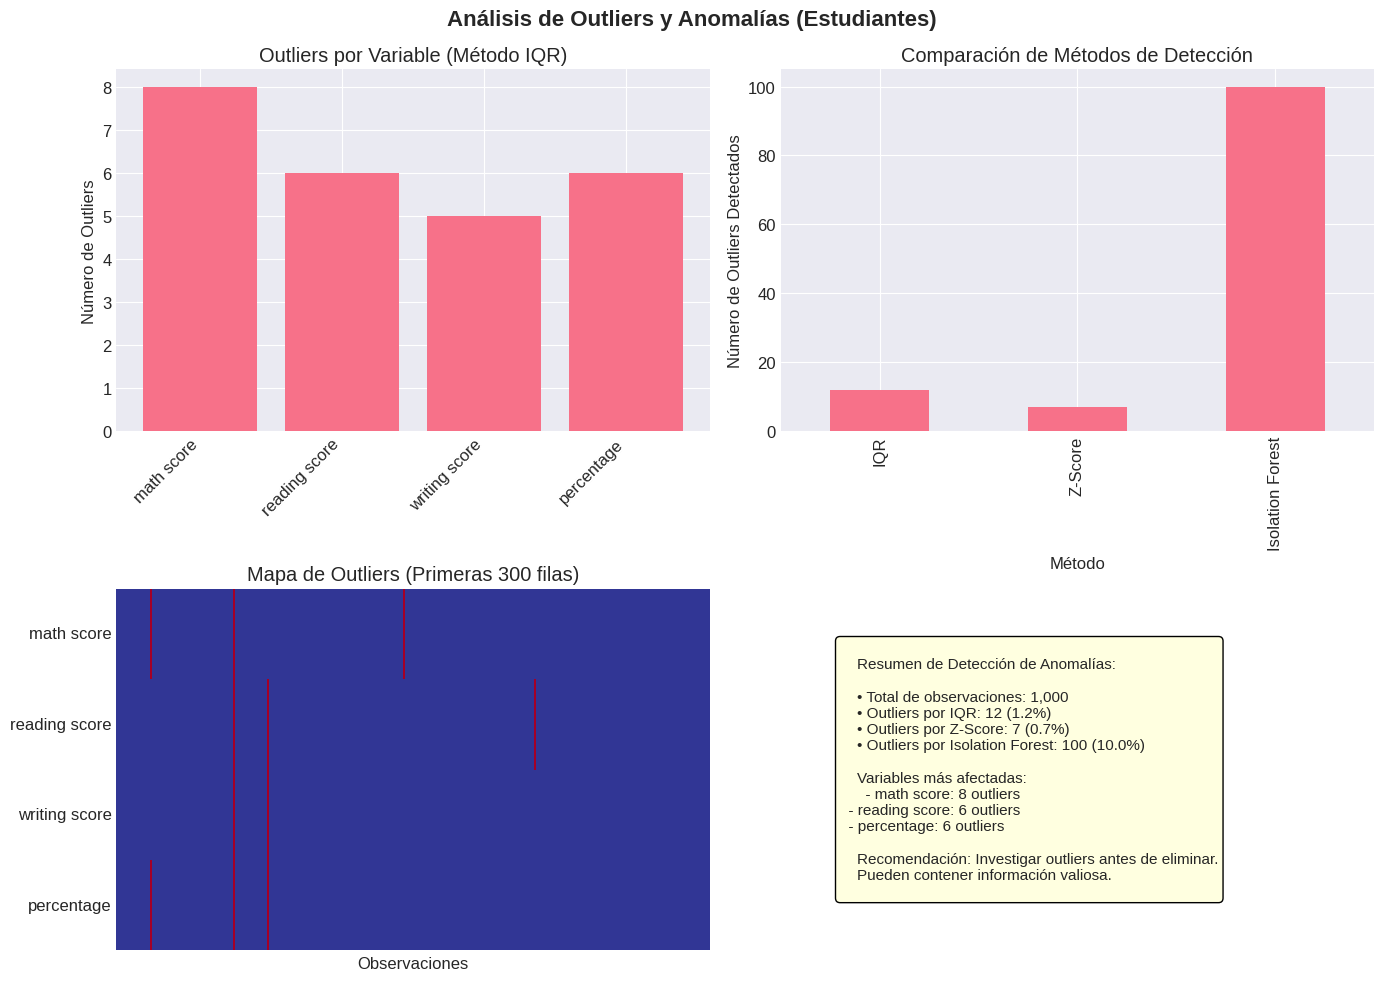

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy import stats

def detect_outliers_students(df):
    """Detección de outliers en dataset de estudiantes con múltiples métodos"""

    numeric_df = df.select_dtypes(include=[np.number])

    # Método 1: IQR
    outliers_iqr = pd.DataFrame()
    for col in numeric_df.columns:
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((numeric_df[col] < Q1 - 1.5 * IQR) |
                   (numeric_df[col] > Q3 + 1.5 * IQR))
        outliers_iqr[col] = outliers

    # Método 2: Z-Score
    z_scores = np.abs(stats.zscore(numeric_df.fillna(numeric_df.median())))
    outliers_zscore = (z_scores > 3)

    # Método 3: Isolation Forest
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df.fillna(numeric_df.median()))
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    outliers_iso = iso_forest.fit_predict(scaled_data) == -1

    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Outliers por columna (IQR)
    ax1 = axes[0, 0]
    outlier_counts = outliers_iqr.sum()
    ax1.bar(range(len(outlier_counts)), outlier_counts.values)
    ax1.set_xticks(range(len(outlier_counts)))
    ax1.set_xticklabels(outlier_counts.index, rotation=45, ha='right')
    ax1.set_title('Outliers por Variable (Método IQR)')
    ax1.set_ylabel('Número de Outliers')

    # Plot 2: Distribución de outliers por método
    ax2 = axes[0, 1]
    methods_comparison = pd.DataFrame({
        'IQR': outliers_iqr.any(axis=1).sum(),
        'Z-Score': outliers_zscore.any(axis=1).sum(),
        'Isolation Forest': outliers_iso.sum()
    }, index=['Outliers'])
    methods_comparison.T.plot(kind='bar', ax=ax2, legend=False)
    ax2.set_title('Comparación de Métodos de Detección')
    ax2.set_ylabel('Número de Outliers Detectados')
    ax2.set_xlabel('Método')

    # Plot 3: Heatmap de outliers
    ax3 = axes[1, 0]
    n_rows = 300
    sample_outliers = outliers_iqr.head(n_rows)
    sns.heatmap(sample_outliers.T, cmap='RdYlBu_r', cbar=False, ax=ax3,
               yticklabels=True, xticklabels=False)
    ax3.set_title(f'Mapa de Outliers (Primeras {n_rows} filas)')
    ax3.set_xlabel('Observaciones')

    # Plot 4: Resumen estadístico
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = f"""
    Resumen de Detección de Anomalías:

    • Total de observaciones: {len(df):,}
    • Outliers por IQR: {outliers_iqr.any(axis=1).sum():,} ({outliers_iqr.any(axis=1).sum()/len(df)*100:.1f}%)
    • Outliers por Z-Score: {outliers_zscore.any(axis=1).sum():,} ({outliers_zscore.any(axis=1).sum()/len(df)*100:.1f}%)
    • Outliers por Isolation Forest: {outliers_iso.sum():,} ({outliers_iso.sum()/len(df)*100:.1f}%)

    Variables más afectadas:
    {chr(10).join([f'  - {col}: {count:,} outliers'
                   for col, count in outlier_counts.nlargest(3).items()])}

    Recomendación: Investigar outliers antes de eliminar.
    Pueden contener información valiosa.
    """
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

    plt.suptitle('Análisis de Outliers y Anomalías (Estudiantes)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return outliers_iqr, outliers_zscore, outliers_iso

# Ejecutar con tu dataset de estudiantes
outliers_iqr, outliers_zscore, outliers_iso = detect_outliers_students(performance)


In [ ]:
def print_outliers_info(df, outliers_iqr, outliers_zscore, outliers_iso):
    """Imprime información detallada de los outliers detectados"""

    print("\n========== Resumen General ==========")
    print(f"Total de observaciones: {len(df)}")
    print(f"Outliers por IQR: {outliers_iqr.any(axis=1).sum()} ({outliers_iqr.any(axis=1).mean()*100:.1f}%)")
    print(f"Outliers por Z-Score: {outliers_zscore.any(axis=1).sum()} ({outliers_zscore.any(axis=1).mean()*100:.1f}%)")
    print(f"Outliers por Isolation Forest: {outliers_iso.sum()} ({outliers_iso.mean()*100:.1f}%)")

    # Identificar índices afectados
    iqr_idx = df[outliers_iqr.any(axis=1)].index
    z_idx = df[outliers_zscore.any(axis=1)].index
    iso_idx = df[outliers_iso].index

    print("\n========== Ejemplos de Outliers ==========")
    print("\n--- Método IQR ---")
    print(df.loc[iqr_idx].head(5))

    print("\n--- Método Z-Score ---")
    print(df.loc[z_idx].head(5))

    print("\n--- Método Isolation Forest ---")
    print(df.loc[iso_idx].head(5))

    # Intersección de métodos
    combined_outliers = set(iqr_idx) & set(z_idx) & set(iso_idx)
    print("\n========== Intersección ==========")
    print(f"Observaciones detectadas como outliers por los 3 métodos: {len(combined_outliers)}")
    if combined_outliers:
        print(df.loc[list(combined_outliers)].head())

print_outliers_info(performance, outliers_iqr, outliers_zscore, outliers_iso)



========== Resumen General ==========
Total de observaciones: 1000
Outliers por IQR: 12 (1.2%)
Outliers por Z-Score: 7 (0.7%)
Outliers por Isolation Forest: 100 (10.0%)

========== Ejemplos de Outliers ==========

--- Método IQR ---
     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
59   female        group C            some high school  free/reduced   
76     male        group E            some high school      standard   
145  female        group C                some college  free/reduced   
211    male        group C                some college  free/reduced   

    test preparation course  math score  reading score  writing score  \
17                     none          18             32             28   
59                     none           0             17             10   
76                     none          30             26             22   
145                    none          22  

# Encodig de features categoricas

Vamos a hacer el encodig de las features que no son númericas

In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

le = LabelEncoder()
oe = OrdinalEncoder(categories=[['PASS', 'FAIL']])

df_columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for col in df_columns:
    performance[col] = le.fit_transform(performance[col])

performance['grade'] = oe.fit_transform(performance[['grade']])

performance.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,percentage,grade
0,0,1,1,1,1,72,72,74,72.67,0.00
1,0,2,4,1,0,69,90,88,82.33,0.00
2,0,1,3,1,1,90,95,93,92.67,0.00
3,1,0,0,0,1,47,57,44,49.33,1.00
4,1,2,4,1,1,76,78,75,76.33,0.00


# Selección de la variable objetivo

El dataset Students Performance in Exams contiene tres puntajes principales:
math score, reading score y writing score. Basados en ellos y dada su correlación, se agregaron dos columnas más: percentage y grade.


Se eligió grade como variable objetivo por las siguientes razones:

1. **Síntesis de información**:  
   `grade` resume el rendimiento general del estudiante en una sola categoría, integrando las tres métricas numéricas principales. Esto permite modelar el desempeño global sin necesidad de predecir tres variables separadas.

2. **Facilidad interpretativa**:  
   La escala A–F es un sistema estándar y fácilmente interpretable tanto en contextos educativos como analíticos. Los resultados del modelo se pueden comunicar claramente a cualquier público.

3. **Clasificación supervisada natural**:  
   Al ser una variable categórica ordinal, `grade` permite aplicar modelos de **clasificación supervisada** (como *Logistic Regression*, *Random Forest*, *SVM*, etc.) para predecir el rendimiento académico, lo que es más intuitivo que usar los puntajes continuos.

4. **Relevancia práctica**:  
   En muchos contextos educativos y de gestión, las decisiones (por ejemplo, apoyo académico, becas, alertas tempranas) se basan en la **letra de calificación**, no en los puntajes exactos. Por tanto, predecir `grade` aporta valor operativo directo.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

sample = RandomUnderSampler(random_state=42)

columns_to_drop = ['math score', 'reading score', 'writing score', 'percentage', 'grade']

X = performance.drop(columns=columns_to_drop)
y = performance["grade"]

print(f"Tamaño del conjunto de datos: {X.shape[0]} filas × {X.shape[1]} columnas")
print(f"Distribución de la variable objetivo:\n{y.value_counts()}")
print()


print(f"Tamaño del conjunto de datos: {X.shape[0]} filas × {X.shape[1]} columnas")
print(f"Distribución de la variable objetivo:\n{y.value_counts()}")
print()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#X_train, y_train = sample.fit_resample(X_train, y_train)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} filas × {X_train.shape[1]} columnas")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} filas × {X_test.shape[1]} columnas")

Tamaño del conjunto de datos: 1000 filas × 5 columnas
Distribución de la variable objetivo:
grade
0.00    715
1.00    285
Name: count, dtype: int64

Tamaño del conjunto de datos: 1000 filas × 5 columnas
Distribución de la variable objetivo:
grade
0.00    715
1.00    285
Name: count, dtype: int64

Tamaño del conjunto de entrenamiento: 800 filas × 5 columnas
Tamaño del conjunto de prueba: 200 filas × 5 columnas


# Baseline

La regresión logística se usa como baseline porque es un modelo simple, rápido e interpretable que ofrece un rendimiento sólido en muchos problemas de clasificación binaria, permitiendo establecer un punto de referencia claro para evaluar si modelos más complejos realmente aportan mejoras significativas.

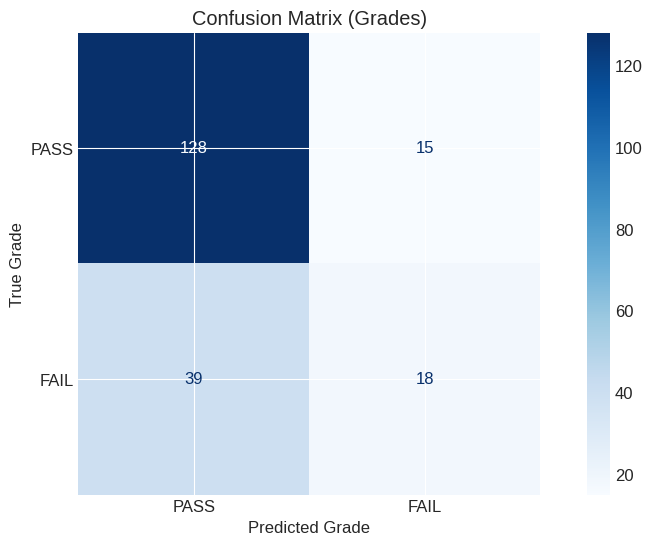

Este modelo no tiene feature importance
=== Baseline Logistic Regression ===
Accuracy: 0.730
F1-score: 0.704

Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.77      0.90      0.83       143
         1.0       0.55      0.32      0.40        57

    accuracy                           0.73       200
   macro avg       0.66      0.61      0.61       200
weighted avg       0.70      0.73      0.70       200



In [ ]:
# Baseline: Regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Entrenamiento del modelo baseline
baseline = LogisticRegression(max_iter=40)
baseline.fit(X_train, y_train)

# Predicciones
y_pred = baseline.predict(X_test)

# Métricas principales
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

grade_labels = ['PASS', 'FAIL']

# Función para mostrar la importancia de cada feature
def plot_feature_importance(model, X):
  if not hasattr(model, "feature_importances_"):
    return print("Este modelo no tiene feature importance")
  importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
  plt.figure(figsize=(6,4))
  sns.barplot(x=importances, y=importances.index, palette='viridis')
  plt.title("Feature Importance for Student Performance Prediction")
  plt.show()

# Función para mostrar matriz de confusión con etiquetas
def make_confusion_matrix(y_test, y_pred, labels, display_labels):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix (Grades)')
    plt.xlabel('Predicted Grade')
    plt.ylabel('True Grade')
    plt.show()

# Mostrar matriz con etiquetas de calificaciones
make_confusion_matrix(y_test, y_pred, labels=[0, 1], display_labels=grade_labels)
plot_feature_importance(baseline, X_train)

# Resultados
print("=== Baseline Logistic Regression ===")
print(f"Accuracy: {acc:.3f}")
print(f"F1-score: {f1:.3f}")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))



# Data Card

**Dataset:** Students Performance in Exams  
**Fuente:** [Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)  
**Tamaño:** {performance.shape[0]} filas × {performance.shape[1]} columnas  
**Variables:** Demográficas (género, raza), socioeconómicas (nivel educativo de los padres, tipo de almuerzo),
académicas (curso de preparación y puntajes).  
**Propósito:** Evaluar factores asociados con el desempeño académico, en particular en matemáticas.  
**Sesgos potenciales:** Representatividad geográfica limitada, diferencias culturales no controladas.  
**Uso previsto:** Análisis educativo y práctica de modelos de predicción.  
**Limitaciones:** No se puede inferir causalidad.



# Comparación de familias de modelos

Para la comparación de diferentes familias de modelos, se va a hacer el entrenamiento del modelos usando los siguientes tipos de modelos de clasificación:

1. Regresión Logística
2. Árbol de Decisión
3. Random Forest
4. Support Vector Machine
5. K-Nearest Neighbors

In [ ]:
!pip install optuna xgboost lightgbm

[I 2025-10-27 00:04:15,055] A new study created in memory with name: no-name-de279eb9-081e-48ae-9580-5899e2271ca9



=============== Regresión Logística (Baseline) ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:04:15,105] Trial 0 finished with value: 0.6837411881764336 and parameters: {'C': 0.23141589819278335, 'solver': 'liblinear'}. Best is trial 0 with value: 0.6837411881764336.
[I 2025-10-27 00:04:15,145] Trial 1 finished with value: 0.6812396158936668 and parameters: {'C': 0.1842391487355359, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.6837411881764336.
[I 2025-10-27 00:04:15,177] Trial 2 finished with value: 0.6899833854298668 and parameters: {'C': 0.020468689679837237, 'solver': 'liblinear'}. Best is trial 2 with value: 0.6899833854298668.
[I 2025-10-27 00:04:15,219] Trial 3 finished with value: 0.6824880553443534 and parameters: {'C': 0.12357750793947492, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.6899833854298668.
[I 2025-10-27 00:04:15,256] Trial 4 finished with value: 0.6799958698243737 and parameters: {'C': 0.4055164886752742, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.6899833854298668.
[I 2025-10-27 00:04:15,306] Trial 5 finished with value: 0

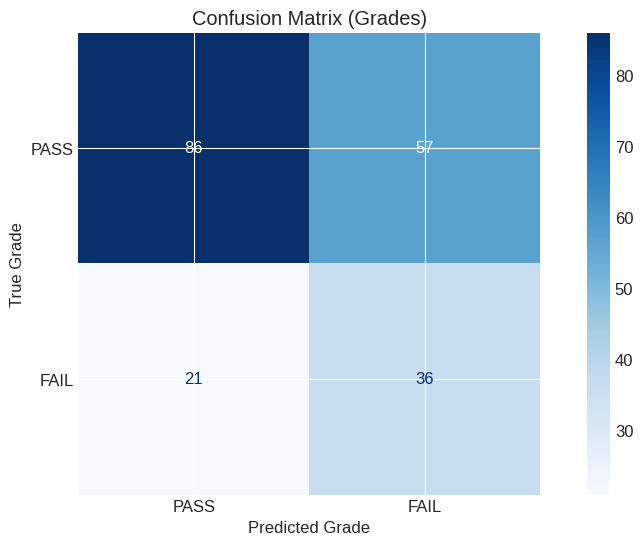

[I 2025-10-27 00:04:16,257] A new study created in memory with name: no-name-0893820d-14f6-4fc9-ad80-5807e95565bb


Este modelo no tiene feature importance
Accuracy: 0.610
F1-score: 0.629

=============== Árbol de Decisión ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:04:16,334] Trial 0 finished with value: 0.6013019439985733 and parameters: {'max_depth': 10, 'min_samples_split': 22, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6013019439985733.
[I 2025-10-27 00:04:16,379] Trial 1 finished with value: 0.5625252269249904 and parameters: {'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6013019439985733.
[I 2025-10-27 00:04:16,427] Trial 2 finished with value: 0.6076192353543033 and parameters: {'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 7, 'criterion': 'entropy'}. Best is trial 2 with value: 0.6076192353543033.
[I 2025-10-27 00:04:16,466] Trial 3 finished with value: 0.6100644870603475 and parameters: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 6, 'criterion': 'entropy'}. Best is trial 3 with value: 0.6100644870603475.
[I 2025-10-27 00:04:16,510] Trial 4 finished with value: 0.6175645105272545 and

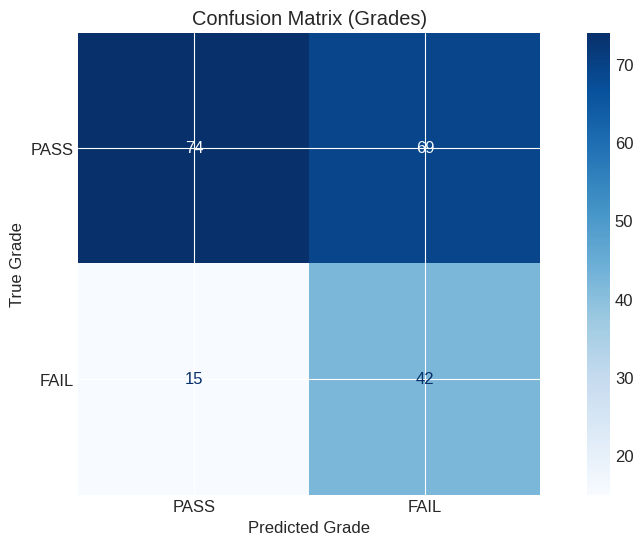

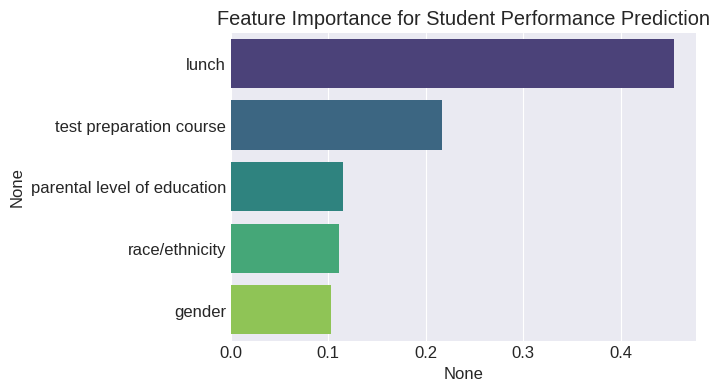

[I 2025-10-27 00:04:17,709] A new study created in memory with name: no-name-06952bf5-2a64-4439-8757-9839c81b0482


Accuracy: 0.580
F1-score: 0.599

=============== Random Forest ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:04:19,792] Trial 0 finished with value: 0.6338317704373293 and parameters: {'n_estimators': 486, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.6338317704373293.
[I 2025-10-27 00:04:20,590] Trial 1 finished with value: 0.6363286493387026 and parameters: {'n_estimators': 188, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.6363286493387026.
[I 2025-10-27 00:04:22,808] Trial 2 finished with value: 0.6463208583255892 and parameters: {'n_estimators': 555, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 2 with value: 0.6463208583255892.
[I 2025-10-27 00:04:24,336] Trial 3 finished with value: 0.646302084800015 and parameters: {'n_estimators': 281, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.6463208583255892

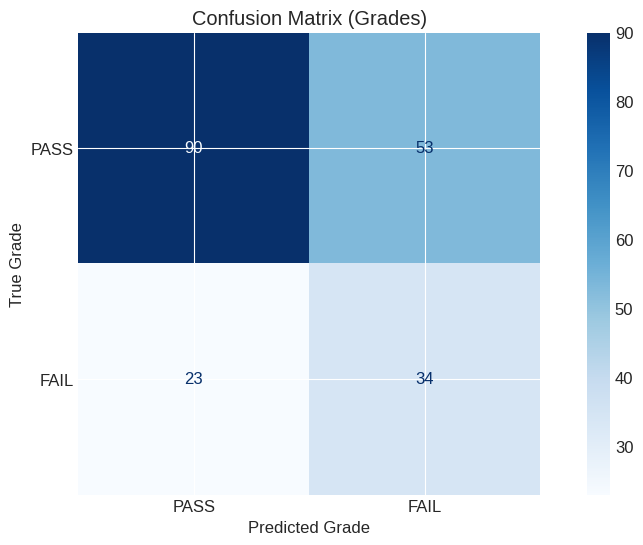

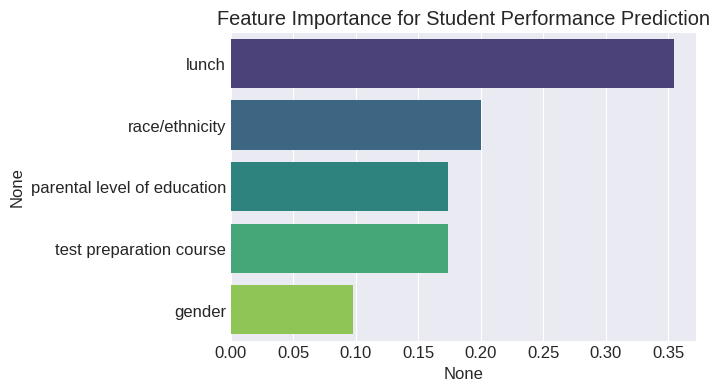

[I 2025-10-27 00:04:51,809] A new study created in memory with name: no-name-c045c683-c54d-4d2c-94ac-8f6215ebdb8d


Accuracy: 0.620
F1-score: 0.637

=============== Gradient Boosting ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:04:52,777] Trial 0 finished with value: 0.6762880985234622 and parameters: {'n_estimators': 320, 'learning_rate': 0.14454808629743993, 'max_depth': 3, 'subsample': 0.8043310420790653}. Best is trial 0 with value: 0.6762880985234622.
[I 2025-10-27 00:04:53,836] Trial 1 finished with value: 0.7037537664385684 and parameters: {'n_estimators': 458, 'learning_rate': 0.18029568689735323, 'max_depth': 2, 'subsample': 0.6828971512552747}. Best is trial 1 with value: 0.7037537664385684.
[I 2025-10-27 00:04:54,170] Trial 2 finished with value: 0.7350022997568829 and parameters: {'n_estimators': 120, 'learning_rate': 0.09375387029362092, 'max_depth': 2, 'subsample': 0.7827332897578845}. Best is trial 2 with value: 0.7350022997568829.
[I 2025-10-27 00:04:55,555] Trial 3 finished with value: 0.6862850008917425 and parameters: {'n_estimators': 360, 'learning_rate': 0.06291258370311531, 'max_depth': 4, 'subsample': 0.8363451269665403}. Best is trial 2 with value: 0.7350022997568829.


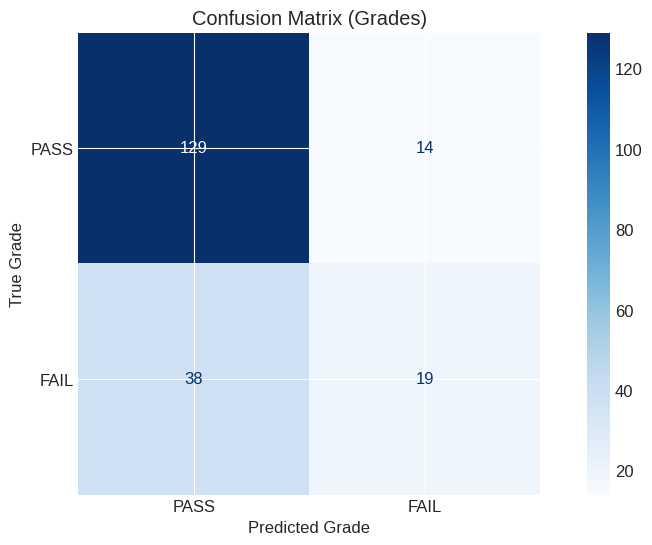

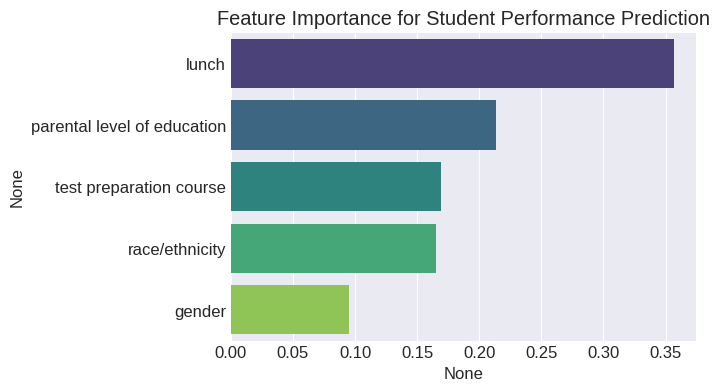

[I 2025-10-27 00:05:10,881] A new study created in memory with name: no-name-2207b070-6a84-476d-ad2d-2f2df0e4bdcf


Accuracy: 0.740
F1-score: 0.715

=============== Naive Bayes ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:05:10,943] Trial 0 finished with value: 0.7312475946420358 and parameters: {'alpha': 1.0507979025745755}. Best is trial 0 with value: 0.7312475946420358.
[I 2025-10-27 00:05:10,988] Trial 1 finished with value: 0.7312475946420358 and parameters: {'alpha': 1.2081478226181048}. Best is trial 0 with value: 0.7312475946420358.
[I 2025-10-27 00:05:11,032] Trial 2 finished with value: 0.7312475946420358 and parameters: {'alpha': 0.7909047389129443}. Best is trial 0 with value: 0.7312475946420358.
[I 2025-10-27 00:05:11,081] Trial 3 finished with value: 0.7312475946420358 and parameters: {'alpha': 1.010827605197663}. Best is trial 0 with value: 0.7312475946420358.
[I 2025-10-27 00:05:11,125] Trial 4 finished with value: 0.7312475946420358 and parameters: {'alpha': 1.3929469543476547}. Best is trial 0 with value: 0.7312475946420358.
[I 2025-10-27 00:05:11,180] Trial 5 finished with value: 0.7312475946420358 and parameters: {'alpha': 1.396293088933438}. Best is trial 0 with val

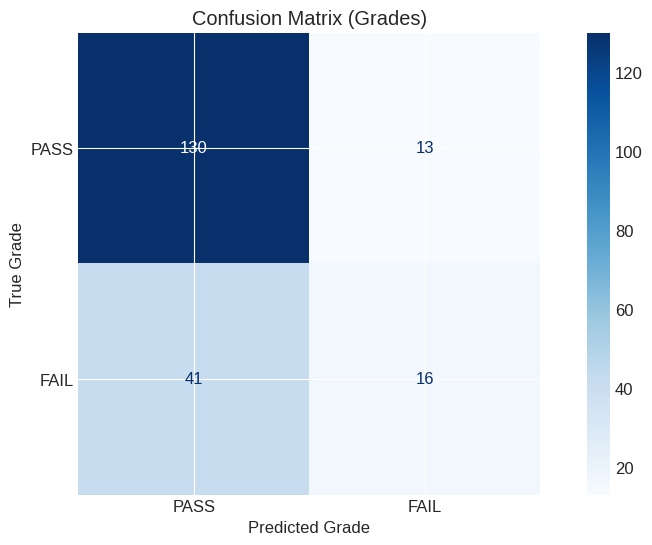

[I 2025-10-27 00:05:12,198] A new study created in memory with name: no-name-3c537409-5388-4c95-864d-eaa4889bba6a


Este modelo no tiene feature importance
Accuracy: 0.730
F1-score: 0.698

=============== K-Nearest Neighbors ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:05:12,285] Trial 0 finished with value: 0.7037772333455362 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.7037772333455362.
[I 2025-10-27 00:05:12,367] Trial 1 finished with value: 0.7212600790365427 and parameters: {'n_neighbors': 28, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.7212600790365427.
[I 2025-10-27 00:05:12,444] Trial 2 finished with value: 0.7062600321027288 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.7212600790365427.
[I 2025-10-27 00:05:12,503] Trial 3 finished with value: 0.7037678465827489 and parameters: {'n_neighbors': 21, 'weights': 'distance', 'p': 2}. Best is trial 1 with value: 0.7212600790365427.
[I 2025-10-27 00:05:12,590] Trial 4 finished with value: 0.6812771629448152 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.7212600790365427.
[I 2025-10-27 00:05:12,662] Trial 5 finished w

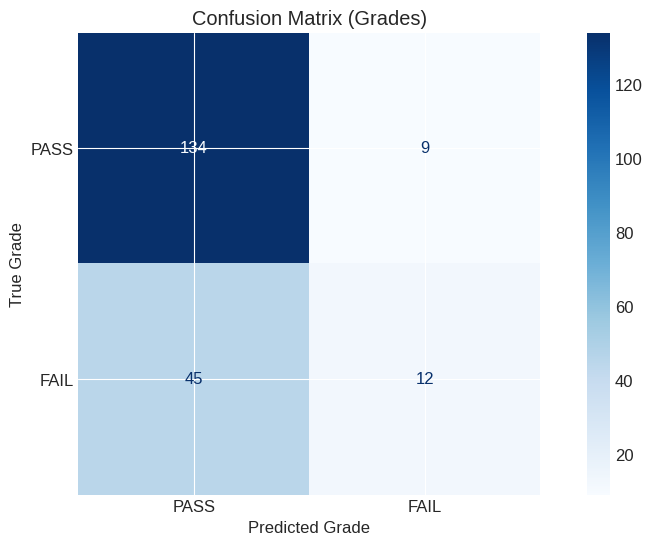

[I 2025-10-27 00:05:14,353] A new study created in memory with name: no-name-8e41c690-6fd3-4092-a7c8-4a995933d19a


Este modelo no tiene feature importance
Accuracy: 0.730
F1-score: 0.683

=============== SVM ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:05:14,566] Trial 0 finished with value: 0.5699923967221424 and parameters: {'C': 1.2635598137381667, 'gamma': 'scale', 'kernel': 'sigmoid'}. Best is trial 0 with value: 0.5699923967221424.
[I 2025-10-27 00:05:14,762] Trial 1 finished with value: 0.6562426665915726 and parameters: {'C': 0.17830791467464946, 'gamma': 'scale', 'kernel': 'sigmoid'}. Best is trial 1 with value: 0.6562426665915726.
[I 2025-10-27 00:05:14,913] Trial 2 finished with value: 0.6662254888156721 and parameters: {'C': 1.9874128578795687, 'gamma': 'auto', 'kernel': 'rbf'}. Best is trial 2 with value: 0.6662254888156721.
[I 2025-10-27 00:05:15,073] Trial 3 finished with value: 0.6624801704636122 and parameters: {'C': 0.32999312639278094, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 2 with value: 0.6662254888156721.
[I 2025-10-27 00:05:15,231] Trial 4 finished with value: 0.5699923967221424 and parameters: {'C': 1.228281854594453, 'gamma': 'scale', 'kernel': 'sigmoid'}. Best is trial 2 with value

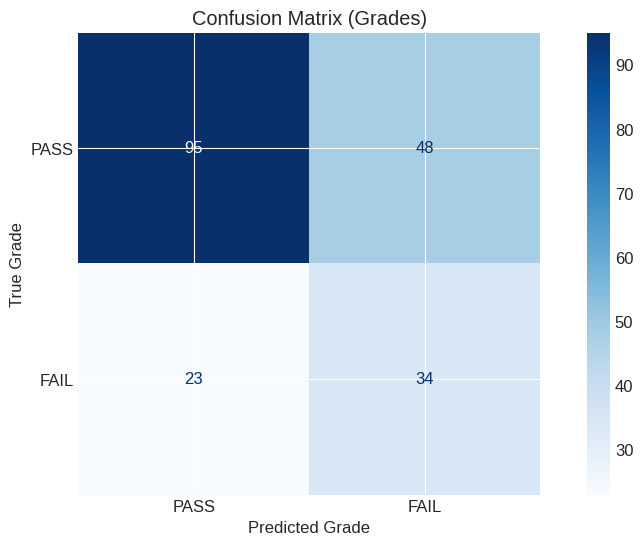

[I 2025-10-27 00:05:18,119] A new study created in memory with name: no-name-36ca4d25-dc71-4192-9f7c-36ed7d1bc8c2


Este modelo no tiene feature importance
Accuracy: 0.645
F1-score: 0.660

=============== XGBoost ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:05:18,313] Trial 0 finished with value: 0.7337350867806219 and parameters: {'n_estimators': 375, 'max_depth': 8, 'learning_rate': 0.09436237428475384, 'subsample': 0.7554138025988315, 'colsample_bytree': 0.9464734771738273, 'gamma': 4.48146544466719}. Best is trial 0 with value: 0.7337350867806219.
[I 2025-10-27 00:05:18,433] Trial 1 finished with value: 0.7249960106258154 and parameters: {'n_estimators': 162, 'max_depth': 4, 'learning_rate': 0.024925488957240664, 'subsample': 0.7204049218253182, 'colsample_bytree': 0.5149381054392834, 'gamma': 2.2841661219735556}. Best is trial 0 with value: 0.7337350867806219.
[I 2025-10-27 00:05:18,576] Trial 2 finished with value: 0.7387382313461556 and parameters: {'n_estimators': 425, 'max_depth': 5, 'learning_rate': 0.20611392157423805, 'subsample': 0.7954314087081754, 'colsample_bytree': 0.5119909411885827, 'gamma': 2.79427043995441}. Best is trial 2 with value: 0.7387382313461556.
[I 2025-10-27 00:05:18,693] Trial 3 finished w

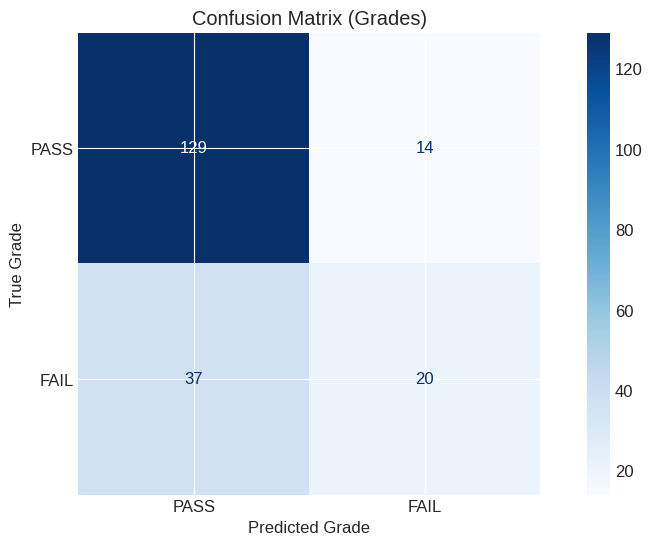

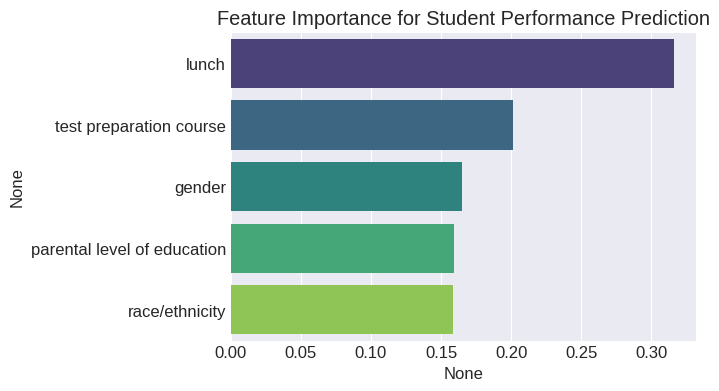

[I 2025-10-27 00:05:22,566] A new study created in memory with name: no-name-dc4fb570-3079-49ef-9e76-bf5188f534cd


Accuracy: 0.745
F1-score: 0.722

=============== LightGBM ===============


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-27 00:05:22,774] Trial 0 finished with value: 0.7262538368392892 and parameters: {'n_estimators': 375, 'num_leaves': 77, 'learning_rate': 0.06527190039345943, 'feature_fraction': 0.7554138025988315, 'bagging_fraction': 0.9464734771738273, 'lambda_l1': 1.7925861778668761, 'lambda_l2': 0.2511706209276725}. Best is trial 0 with value: 0.7262538368392892.
[I 2025-10-27 00:05:22,927] Trial 1 finished with value: 0.7337538603061962 and parameters: {'n_estimators': 203, 'num_leaves': 24, 'learning_rate': 0.09375387029362092, 'feature_fraction': 0.5149381054392834, 'bagging_fraction': 0.7284166121973555, 'lambda_l1': 1.2982880952295215, 'lambda_l2': 0.5569745652959506}. Best is trial 1 with value: 0.7337538603061962.
[I 2025-10-27 00:05:23,220] Trial 2 finished with value: 0.7212694657993297 and parameters: {'n_estimators': 438, 'num_leaves': 67, 'learning_rate': 0.01455655765166142, 'feature_fraction': 0.7794270439954409, 'bagging_fraction': 0.6296262234537326, 'lambda_l1': 0.83020

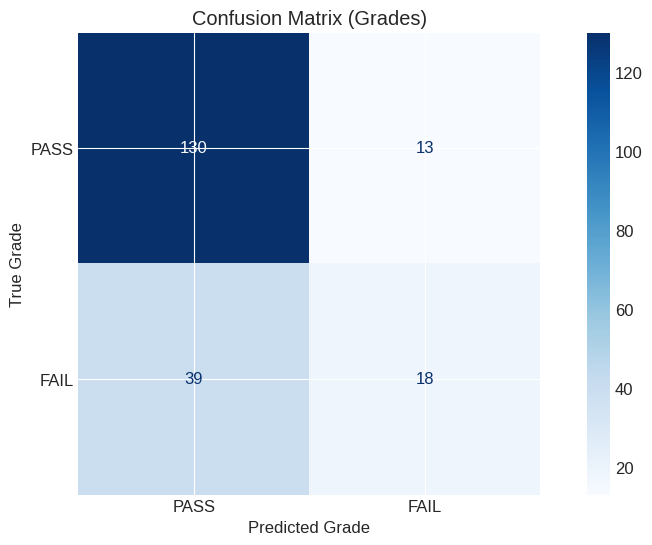

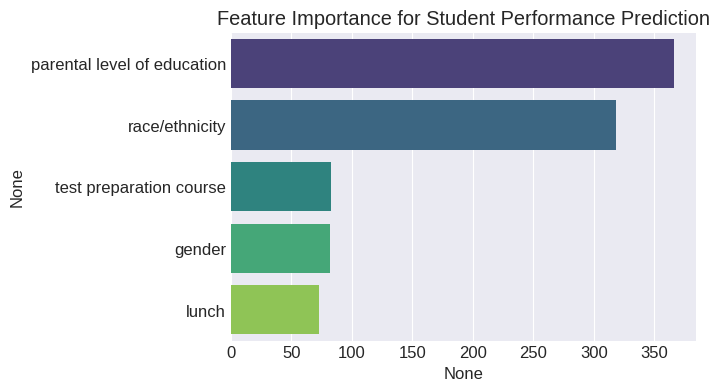

Accuracy: 0.740
F1-score: 0.712


,Modelo,Accuracy,Accuracy train,F1-score,F1-score train
7,XGBoost,0.74,0.74,0.72,0.72
8,LightGBM,0.74,0.76,0.71,0.73
3,Gradient Boosting,0.74,0.76,0.72,0.73
5,K-Nearest Neighbors,0.73,0.74,0.68,0.70
4,Naive Bayes,0.73,0.74,0.70,0.69
6,SVM,0.65,0.70,0.66,0.71
2,Random Forest,0.62,0.71,0.64,0.72
0,Regresión Logística (Baseline),0.61,0.69,0.63,0.70
1,Árbol de Decisión,0.58,0.66,0.60,0.67



=============== Best parameters summary ===============


,C,solver,max_depth,min_samples_split,min_samples_leaf,criterion,n_estimators,max_features,learning_rate,subsample,alpha,n_neighbors,weights,p,gamma,kernel,colsample_bytree,num_leaves,feature_fraction,bagging_fraction,lambda_l1,lambda_l2
Regresión Logística (Baseline),0.02,liblinear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Árbol de Decisión,NaN,NaN,5,30,7,gini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Random Forest,NaN,NaN,5,8,1,NaN,201,sqrt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gradient Boosting,NaN,NaN,2.00,NaN,NaN,NaN,207.00,NaN,0.06,0.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Naive Bayes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K-Nearest Neighbors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26,uniform,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVM,0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,auto,poly,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,NaN,NaN,7.00,NaN,NaN,NaN,469.00,NaN,0.16,0.54,NaN,NaN,NaN,NaN,2.32,NaN,0.59,NaN,NaN,NaN,NaN,NaN
LightGBM,NaN,NaN,NaN,NaN,NaN,NaN,203.00,NaN,0.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.00,0.51,0.73,1.30,0.56


In [ ]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# New imports
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

random_state = 3
scaler = MinMaxScaler()
results = []
best_params_dict = {}

# Base models (without tuning)
models = {
    "Regresión Logística (Baseline)": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state),
    "Árbol de Decisión": DecisionTreeClassifier(class_weight="balanced", random_state=random_state),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=random_state, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=random_state),
    "Naive Bayes": CategoricalNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_jobs=-1),
    "SVM": SVC(class_weight="balanced", probability=True, random_state=random_state),
    "XGBoost": XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(random_state=random_state),
}

# Optuna tuning for each model
for name, base_model in models.items():
    print(f"\n=============== {name} ===============")

    def objective(trial):
        if isinstance(base_model, LogisticRegression):
            params = {
                "C": trial.suggest_float("C", 0.01, 3.0, log=True),
                "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
            }
            model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state, **params)

        elif isinstance(base_model, DecisionTreeClassifier):
            params = {
                "max_depth": trial.suggest_int("max_depth", 3, 15),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
                "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
            }
            model = DecisionTreeClassifier(class_weight="balanced", random_state=random_state, **params)

        elif isinstance(base_model, RandomForestClassifier):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 800),
                "max_depth": trial.suggest_int("max_depth", 5, 25),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
            }
            model = RandomForestClassifier(class_weight="balanced", random_state=random_state, n_jobs=-1, **params)

        elif isinstance(base_model, GradientBoostingClassifier):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 500),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
                "max_depth": trial.suggest_int("max_depth", 2, 5),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            }
            model = GradientBoostingClassifier(random_state=random_state, **params)

        elif isinstance(base_model, CategoricalNB):
            params = {"alpha": trial.suggest_float("alpha", 0.5, 1.5)}
            model = CategoricalNB(**params)

        elif isinstance(base_model, KNeighborsClassifier):
            params = {
                "n_neighbors": trial.suggest_int("n_neighbors", 3, 30),
                "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
                "p": trial.suggest_int("p", 1, 2),
            }
            model = KNeighborsClassifier(n_jobs=-1, **params)

        elif isinstance(base_model, SVC):
            params = {
                "C": trial.suggest_float("C", 0.1, 10, log=True),
                "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
                "kernel": trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"]),
            }
            model = SVC(class_weight="balanced", probability=True, random_state=random_state, **params)

        elif isinstance(base_model, XGBClassifier):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 600),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "gamma": trial.suggest_float("gamma", 0, 5),
            }
            model = XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric="mlogloss", **params)

        elif isinstance(base_model, LGBMClassifier):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 600),
                "num_leaves": trial.suggest_int("num_leaves", 20, 100),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
                "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
                "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
                "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 2.0),
                "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 2.0),
            }
            model = LGBMClassifier(random_state=random_state, **params)

        pipe = Pipeline([("scaler", scaler), ("classifier", model)])
        score = cross_val_score(pipe, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1).mean()
        return score

    # Run optimization
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=25, show_progress_bar=True)

    print("Best parameters:", study.best_params)
    best_params_dict[name] = study.best_params

    # Refit best model
    best_model = base_model.set_params(**study.best_params)
    pipe = Pipeline([("scaler", scaler), ("classifier", best_model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_pred_train = pipe.predict(X_train)

    acc = accuracy_score(y_test, y_pred)
    acc_train = accuracy_score(y_train, y_pred_train)
    f1 = f1_score(y_test, y_pred, average="weighted")
    f1_train = f1_score(y_train, y_pred_train, average="weighted")

    results.append({
        "Modelo": name,
        "Accuracy": acc,
        "Accuracy train": acc_train,
        "F1-score": f1,
        "F1-score train": f1_train
    })

    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
    make_confusion_matrix(y_test, y_pred, labels=[0, 1], display_labels=grade_labels)
    plot_feature_importance(best_model, X_train)
    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score: {f1:.3f}")

# Summary tables
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(results_df)

print("\n=============== Best parameters summary ===============")
best_params_df = pd.DataFrame(best_params_dict).T
display(best_params_df)

